# Figure 4: Perfumer Collaboration Networks and Homophily

Panels of Figure 4 plus SI Figures S11, S12, S13: the perfumer collaboration network and tests for stylistic homophily/contagion. Covers the collaboration trend over time, the network visualization, time-respecting drivers of collaboration, note/accord contagion across social distance, centrality vs complexity/novelty, and disruption (CD) of collaborative vs solo perfumers.

### Figure 4A: Collaboration Trend Over Time

Parses perfumer names, flags perfumes with multiple credited perfumers as collaborations, and plots collaborative perfumes per year (1970-2024). Also computes each perfumer's dominant accord for the network visualization.

Alberto Morillas has 499 perfumes.


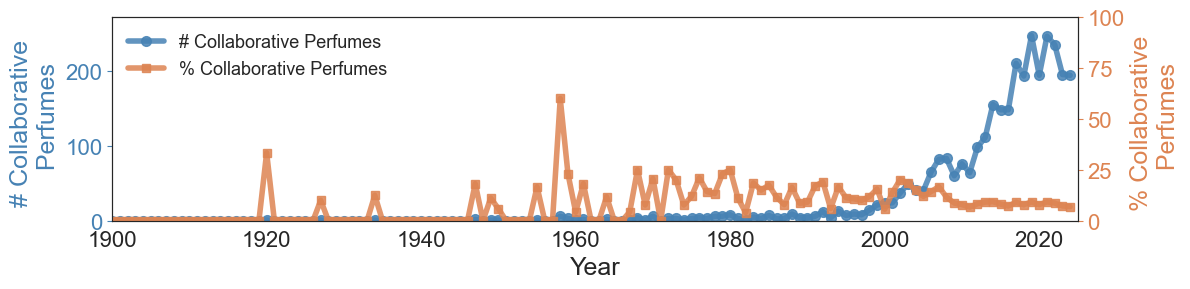

In [1]:
# ===========================================================================
import matplotlib as _mpl
_mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial', 'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
    'svg.fonttype': 'path',          
    'pdf.fonttype': 42, 'ps.fonttype': 42,  
})
# ===========================================================================
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from utils.utils import (
    parse_perfumer, clean_perfumer_artifacts, parse_accords_dict, calculate_dominant_accord
)

def main():
    csv_file = "../dataset/Fragrantica.csv"
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"File {csv_file} not found!")
        return

    if 'year' in df.columns:
        df = df.dropna(subset=['year'])
        df['year'] = df['year'].astype(int)

    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumer)
    df['parsed_perfumers'] = [clean_perfumer_artifacts(ps, hs)
                              for ps, hs in zip(df['parsed_perfumers'], df['brand'])]
    df['parsed_accords'] = df['accords'].apply(parse_accords_dict)

    accord_data = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords.items():
                accord_data.append({'perfumer': perfumer, 'accord': accord, 'frequency': frequency})
    perfumer_accords = pd.DataFrame(accord_data)

    top_accords = (
        perfumer_accords.groupby('accord')['frequency']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .index.tolist()
    )

    dominant_accords = calculate_dominant_accord(perfumer_accords)
    perfumer_accord_map = dominant_accords.set_index('perfumer')['dominant_accord'].to_dict()

    perfumer_counts = (
        df.explode('parsed_perfumers')
        .dropna(subset=['parsed_perfumers'])
        .groupby('parsed_perfumers')['id']
        .count()
        .reset_index()
        .rename(columns={'parsed_perfumers': 'perfumer', 'id': 'perfume_count'})
    )
    alberto = perfumer_counts[perfumer_counts['perfumer'].str.lower() == 'alberto morillas']
    if not alberto.empty:
        print("Alberto Morillas has", alberto['perfume_count'].values[0], "perfumes.")

    perfumer_size_map = perfumer_counts.set_index('perfumer')['perfume_count'].to_dict()

    authored_df = df[df['parsed_perfumers'].apply(len) >= 1]
    total_year_counts = authored_df.groupby('year').size().sort_index()

    top_perfumers = perfumer_counts[perfumer_counts['perfume_count'] > 1]['perfumer'].tolist()
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_perfumers])
    df = df[df['filtered_perfumers'].apply(len) > 1]

    if 'year' in df.columns:
        collab_df = df[(df['year'] >= 1900) & (df['year'] <= 2024)]
        collab_year_counts = collab_df.groupby('year').size().sort_index()

        years = list(range(1900, 2025))
        year_counts = [collab_year_counts.get(y, 0) for y in years]
        year_fractions = [
            (100.0 * collab_year_counts.get(y, 0) / total_year_counts.get(y, 0)
             if total_year_counts.get(y, 0) > 0 else 0.0)
            for y in years
        ]

        sns.set_style("white")
        BLUE, ORANGE = 'steelblue', '#DD8452'
        fig, ax = plt.subplots(figsize=(12, 3))
        ax2 = ax.twinx()
        l1, = ax.plot(years, year_counts, color=BLUE, alpha=0.85, linewidth=4,
                      marker='o', markersize=7, label='# Collaborative Perfumes')
        l2, = ax2.plot(years, year_fractions, color=ORANGE, alpha=0.85, linewidth=4,
                       marker='s', markersize=6, label='% Collaborative Perfumes')
        ax.set_xlabel("Year", fontsize=18)
        ax.set_ylabel("# Collaborative \n Perfumes", fontsize=18, color=BLUE)
        ax2.set_ylabel("% Collaborative \n Perfumes", fontsize=18, color=ORANGE)
        ax.tick_params(axis='x', which='major', labelsize=16)
        ax.tick_params(axis='y', which='major', labelsize=16, colors=BLUE)
        ax2.tick_params(axis='y', which='major', labelsize=16, colors=ORANGE)
        ax.set_xlim(1900, 2025)
        vis = [(1900 <= y <= 2024) for y in years]
        cmax = max([c for c, m in zip(year_counts, vis) if m] or [1])
        fmax = max([f for f, m in zip(year_fractions, vis) if m] or [1])
        ax.set_ylim(0, cmax * 1.1); ax2.set_ylim(0, 100)
        ax.legend(handles=[l1, l2], loc='upper left', frameon=False, fontsize=13)
        plt.tight_layout()
        plt.savefig("../output/Figure_4A.svg", format="svg", dpi=300, bbox_inches="tight")
        plt.show()

if __name__ == "__main__":
    main()

### Figure 4B: Collaboration Network Visualization

Perfumer collaboration network (nodes = perfumers, edges weighted by shared perfumes). Keeps the giant component's k-core, detects communities (greedy modularity), and draws a spring layout: node size = number of perfumes, node color = community (or dominant accord via `COLOR_BY`), edges black within / gray between communities. Top hubs are labeled.

Network shown: 219 perfumers, 1082 collaborations (giant component, 3-core)
Layout seed 0, rotate 354deg, flip 1 (auto-chosen to clear the lower-left for 4j)


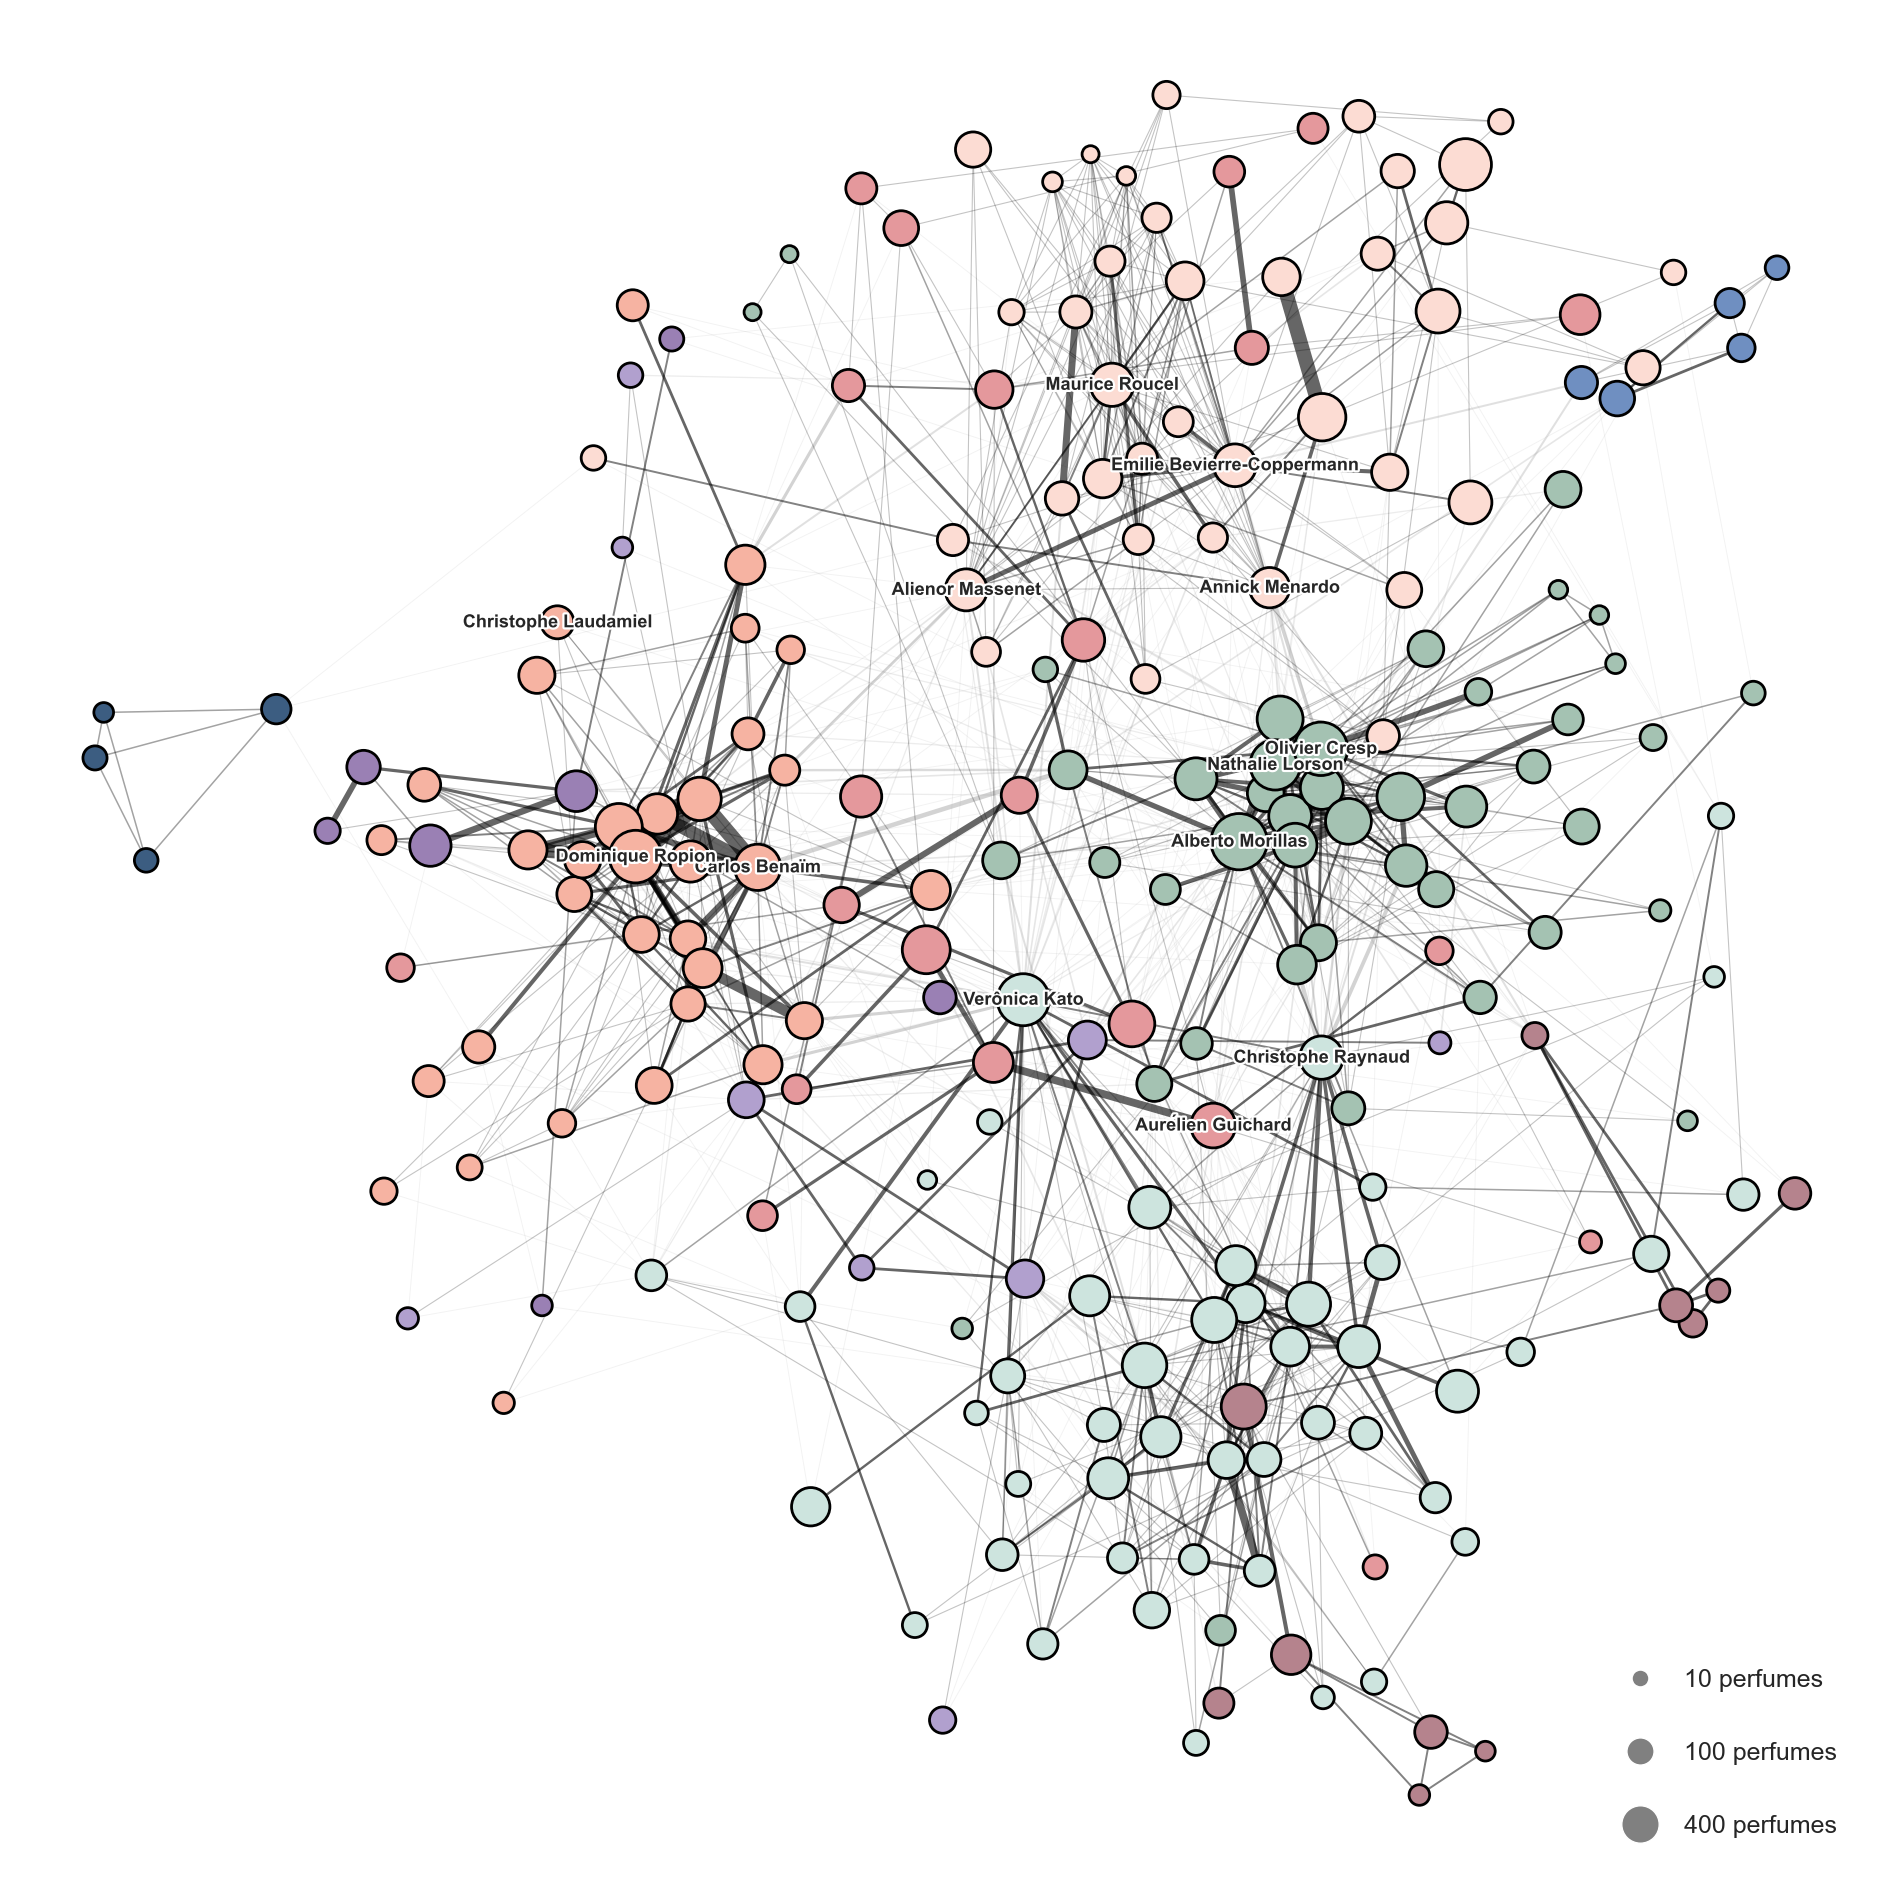


Top collaborators (degree | perfumes made):
   deg  44 |  357 perfumes  Verônica Kato
   deg  36 |  499 perfumes  Alberto Morillas
   deg  34 |  401 perfumes  Olivier Cresp
   deg  31 |  153 perfumes  Emilie Bevierre-Coppermann
   deg  29 |  216 perfumes  Carlos Benaïm
   deg  28 |  163 perfumes  Christophe Raynaud
   deg  28 |  161 perfumes  Maurice Roucel
   deg  27 |  142 perfumes  Alienor Massenet
   deg  27 |  119 perfumes  Annick Menardo
   deg  27 |  311 perfumes  Nathalie Lorson
   deg  25 |  187 perfumes  Aurélien Guichard
   deg  24 |  375 perfumes  Dominique Ropion


In [2]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
from utils.utils import parse_perfumer, clean_perfumer_artifacts, parse_accords_dict
try:
    from adjustText import adjust_text
    _HAVE_ADJUST = True
except Exception:
    _HAVE_ADJUST = False

def main():
    MIN_CORE   = 3
    K_SPREAD   = 1.9
    PULL_IN    = 0.40
    PULL_Q     = 0.75
    N_LABELS   = 12
    SIZE_BASE  = 80
    SIZE_SCALE = 70
    COLOR_BY   = 'community'
    SHOW_HULLS = False
    CLEAR_W, CLEAR_H = 0.50, 0.40
    MARGIN     = 0.05
    N_SEEDS    = 10

    df = pd.read_csv("../dataset/Fragrantica.csv")
    df = df[df['year'] >= 1900]
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumer)
    df['parsed_perfumers'] = [clean_perfumer_artifacts(ps, hs)
                              for ps, hs in zip(df['parsed_perfumers'], df['brand'])]
    pcount = Counter(n for lst in df['parsed_perfumers'] for n in lst)
    nsize = lambda n: SIZE_BASE + SIZE_SCALE * np.sqrt(pcount.get(n, 1))

    edge_w = {}
    for perfs in df['parsed_perfumers']:
        for a, b in combinations(sorted(set(perfs)), 2):
            edge_w[(a, b)] = edge_w.get((a, b), 0) + 1
    G = nx.Graph()
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=w)
    if G.number_of_nodes() == 0:
        print("Empty network."); return
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    G = nx.k_core(G, MIN_CORE)
    H = nx.Graph(); H.add_nodes_from(sorted(G.nodes())); H.add_edges_from(G.edges(data=True)); G = H
    deg = dict(G.degree())
    print(f"Network shown: {G.number_of_nodes()} perfumers, {G.number_of_edges()} collaborations "
          f"(giant component, {MIN_CORE}-core)")

    comms = nx.community.louvain_communities(G, weight='weight', seed=42)
    cm = {n: i for i, c in enumerate(comms) for n in c}
    PALETTE = ['#CDE4DE', '#A4C2B2', '#FCDCD3', '#F6B3A2', '#E4989C',
               '#B5838D', '#B1A0CE', '#9A80B4', '#6F8FC1', '#3C5D81']
    big = [c for c, _ in Counter(cm.values()).most_common(len(PALETTE))]
    cpal = PALETTE; cci = {c: i for i, c in enumerate(big)}

    if COLOR_BY == 'community':
        node_color = {n: (cpal[cci[cm[n]]] if cm[n] in cci else (0.86, 0.86, 0.86)) for n in G.nodes()}
        acc_legend = None
    else:
        freq = defaultdict(Counter)
        for perfs, acc in zip(df['parsed_perfumers'], df['accords'].apply(parse_accords_dict)):
            if isinstance(acc, dict):
                for p in perfs:
                    for a, f in acc.items():
                        freq[p][a] += f
        dom = {p: (c.most_common(1)[0][0] if c else 'other') for p, c in freq.items()}
        top_acc = [a for a, _ in Counter(dom.get(n) for n in G.nodes()).most_common(12)]
        apal = sns.color_palette("tab20", len(top_acc)); aci = {a: i for i, a in enumerate(top_acc)}
        node_color = {n: (apal[aci[dom.get(n)]] if dom.get(n) in aci else (0.86, 0.86, 0.86)) for n in G.nodes()}
        acc_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor=apal[aci[a]],
                             markersize=12, label=a) for a in top_acc]

    nodes = list(G.nodes())
    wts = np.array([nsize(n) for n in nodes])

    def _pull_outliers(L, order, q, f):
        P = np.array([L[n] for n in order]); cen = P.mean(0); d = P - cen; rr = np.linalg.norm(d, axis=1)
        r0 = np.quantile(rr, q); nr = np.where(rr > r0, r0 + (rr - r0) * f, rr)
        sc = np.divide(nr, rr, out=np.ones_like(rr), where=rr > 0)
        return {n: cen + d[i] * sc[i] for i, n in enumerate(order)}
    best = None
    for seed in range(N_SEEDS):
        L = nx.spring_layout(G, k=K_SPREAD, iterations=500, weight='weight', seed=seed)
        if PULL_IN < 1.0:
            L = _pull_outliers(L, nodes, PULL_Q, PULL_IN)
        P = np.array([L[n] for n in nodes]); P = P - P.mean(0)
        for flip in (1, -1):
            Pf = P * np.array([flip, 1.0])
            for a in range(0, 360, 6):
                th = np.radians(a); R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
                Q = Pf @ R.T
                x0, y0 = Q[:, 0].min(), Q[:, 1].min(); W, H = Q[:, 0].max() - x0, Q[:, 1].max() - y0
                in_ll = (Q[:, 0] < x0 + CLEAR_W * W) & (Q[:, 1] < y0 + CLEAR_H * H)
                sc = wts[in_ll].sum()
                if best is None or sc < best[0]:
                    best = (sc, seed, a, flip, Q)
    _, seed_b, rot, flip, Q = best
    pos = {n: Q[i] for i, n in enumerate(nodes)}
    xs, ys = Q[:, 0], Q[:, 1]; Wd, Hd = xs.max() - xs.min(), ys.max() - ys.min()
    print(f"Layout seed {seed_b}, rotate {rot}deg, flip {flip} (auto-chosen to clear the lower-left for 4j)")

    sns.set_style("white")
    fig, ax = plt.subplots(figsize=(19, 19))

    if SHOW_HULLS:
        from scipy.spatial import ConvexHull
        for c in big:
            pts = np.array([pos[n] for n in G.nodes() if cm[n] == c])
            if len(pts) < 4:
                continue
            d = np.linalg.norm(pts - pts.mean(0), axis=1)
            keep = pts[d <= np.quantile(d, 0.75)]
            if len(keep) >= 3:
                try:
                    h = ConvexHull(keep)
                    ax.add_patch(Polygon(keep[h.vertices], closed=True, facecolor=cpal[cci[c]],
                                         alpha=0.07, edgecolor='none', zorder=0))
                except Exception:
                    pass

    for u, v in G.edges():
        if not (cm[u] == cm[v] and cm[u] in cci):
            w = G[u][v]['weight']
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=(0.62, 0.62, 0.62, min(0.45, 0.06 * w + 0.07)),
                    lw=0.4 + 0.26 * w, zorder=1, solid_capstyle='round')
    for u, v in G.edges():
        if cm[u] == cm[v] and cm[u] in cci:
            w = G[u][v]['weight']
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=(0, 0, 0, min(0.6, 0.13 * w + 0.10)),
                    lw=0.5 + 0.30 * w, zorder=2, solid_capstyle='round')

    order = sorted(G.nodes(), key=lambda n: pcount.get(n, 1))
    ax.scatter([pos[n][0] for n in order], [pos[n][1] for n in order],
               s=[nsize(n) for n in order], c=[node_color[n] for n in order],
               edgecolors='black', linewidths=2, zorder=3)

    _label_nodes = [n for n, _ in sorted(deg.items(), key=lambda kv: -kv[1])[:N_LABELS]]
    _label_nodes += [n for n in G.nodes() if 'laudamiel' in n.lower() and n not in _label_nodes]  #label Christophe Laudamiel
    texts = [ax.text(*pos[n], n, fontsize=13, fontweight='bold', ha='center', va='center', zorder=7,
                     path_effects=[pe.withStroke(linewidth=3.2, foreground='white')])
             for n in _label_nodes]

    ax.set_xlim(xs.min() - MARGIN * Wd, xs.max() + MARGIN * Wd)
    ax.set_ylim(ys.min() - MARGIN * Hd, ys.max() + MARGIN * Hd)

    ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                              markersize=np.sqrt(SIZE_BASE + SIZE_SCALE * np.sqrt(c)) * 0.7,
                              label=f"{c} perfumes") for c in (10, 100, 400)],
              loc='lower right', fontsize=18, frameon=False, labelspacing=2.0, borderpad=1.2)
    if acc_legend:
        ax.add_artist(plt.legend(handles=acc_legend, loc='lower left', fontsize=18,
                                 frameon=False, title="Dominant accord"))

    ax.axis('off')
    plt.tight_layout()
    plt.savefig("../output/Figure_4B.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nTop collaborators (degree | perfumes made):")
    for n, d in sorted(deg.items(), key=lambda kv: -kv[1])[:N_LABELS]:
        print(f"   deg {d:3d} | {pcount.get(n,0):4d} perfumes  {n}")

if __name__ == "__main__":
    main()

### Figure 4C: Drivers of Collaboration (Pre-Collaboration, Causal)

Tests whether pre-existing affiliation/similarity predicts that a perfumer pair later collaborates, respecting the arrow of time: every pairwise predictor uses only each perfumer's works before their first joint release (year < T); non-collaborating pairs get a time-matched pseudo-T. Standardized OLS with BH-FDR, drawn as a coefficient forest plot (as in Figure 2E). Shared house and era proximity are the strongest causes; pre-existing note/accord similarity matters little (resemblance mostly emerges after collaborating).

pairs: 1091 collaborating, 6546 non-collaborating (features measured strictly before collaboration)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     279.7
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          1.67e-275
Time:                        13:23:56   Log-Likelihood:                -2174.9
No. Observations:                7637   AIC:                             4362.
Df Residuals:                    7631   BIC:                             4403.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

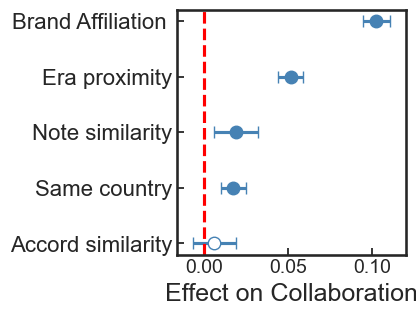


Pre-collaboration drivers (standardized OLS, strongest first; * = BH-FDR<0.05):
  Brand Affiliation  +0.1023  [+0.0941, +0.1106]  *
  Era proximity      +0.0513  [+0.0439, +0.0588]  *
  Note similarity    +0.0189  [+0.0060, +0.0318]  *
  Same country       +0.0173  [+0.0098, +0.0248]  *
  Accord similarity  +0.0060  [-0.0067, +0.0186]  n.s.


In [3]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from collections import Counter, defaultdict
from itertools import combinations
from math import sqrt
from utils.utils import parse_perfumer, clean_perfumer_artifacts, parse_accords_dict, parse_notes

def main():
    SEED, NEG_RATIO, MIN_PRE = 42, 6, 1
    rng = np.random.default_rng(SEED)
    sns.set_theme(style="white", context="talk")

    df = pd.read_csv("../dataset/Fragrantica.csv",
                     usecols=['perfumer', 'brand', 'Country', 'year', 'accords', 'notes', 'id'])
    df = df[df['year'] >= 1900].copy()
    df['pp'] = [clean_perfumer_artifacts(parse_perfumer(p), h)
                for p, h in zip(df['perfumer'], df['brand'])]

    timeline = defaultdict(list)
    ew, eyear = {}, {}
    for _, r in df.iterrows():
        ps = r['pp']
        if not ps:
            continue
        y = r['year']
        ctry = r['Country'] if isinstance(r['Country'], str) else None
        hs = r['brand'].strip() if isinstance(r['brand'], str) else None
        acc = parse_accords_dict(r['accords']); acc = acc if isinstance(acc, dict) else {}
        nts = parse_notes(r['notes'])
        for p in ps:
            timeline[p].append((y, ctry, hs, acc, nts))
        for a, b in combinations(sorted(set(ps)), 2):
            ew[(a, b)] = ew.get((a, b), 0) + 1
            eyear[(a, b)] = min(eyear.get((a, b), 9999), y)
    G = nx.Graph()
    for (u, v), w in ew.items():
        G.add_edge(u, v, weight=w)
    if G.number_of_edges() == 0:
        print("No collaborations."); return
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    nodes = set(G.nodes())

    cache = {}
    def pre(p, T):
        key = (p, T)
        if key not in cache:
            ws = [w for w in timeline[p] if w[0] < T]
            if not ws:
                cache[key] = None
            else:
                cc = Counter(w[1] for w in ws if w[1]); hh = set(w[2] for w in ws if w[2])
                av, nv = Counter(), Counter()
                for _, _, _, acc, nts in ws:
                    for a, f in acc.items(): av[a] += f
                    for n in nts: nv[n] += 1
                cache[key] = dict(country=(cc.most_common(1)[0][0] if cc else None), houses=hh,
                                  era=float(np.median([w[0] for w in ws])),
                                  av=av, an=(sqrt(sum(x*x for x in av.values())) or 1.0),
                                  nv=nv, nn=(sqrt(sum(x*x for x in nv.values())) or 1.0), n=len(ws))
        return cache[key]

    def cos(a, na, b, nb):
        return sum(a[x] * b.get(x, 0) for x in a) / (na * nb) if a and b else 0.0

    def feats(u, v, T):
        pu, pv = pre(u, T), pre(v, T)
        if pu is None or pv is None or pu['n'] < MIN_PRE or pv['n'] < MIN_PRE:
            return None
        return dict(same_country=1.0 if pu['country'] and pu['country'] == pv['country'] else 0.0,
                    same_house=1.0 if pu['houses'] & pv['houses'] else 0.0,
                    era_prox=-abs(pu['era'] - pv['era']),
                    accord_sim=cos(pu['av'], pu['an'], pv['av'], pv['an']),
                    note_sim=cos(pu['nv'], pu['nn'], pv['nv'], pv['nn']))

    pos = []
    for (u, v) in G.edges():
        T = min(eyear.get((u, v), 9999), eyear.get((v, u), 9999))
        if T == 9999:
            continue
        f = feats(u, v, T)
        if f:
            f['y'] = 1; pos.append(f)
    pos_years = [eyear[(u, v)] for (u, v) in G.edges() if eyear.get((u, v), 9999) != 9999]

    nodel = list(nodes); eset = set(map(frozenset, G.edges()))
    neg, tries = [], 0
    while len(neg) < len(pos) * NEG_RATIO and tries < len(pos) * NEG_RATIO * 40:
        tries += 1
        u, v = (str(x) for x in rng.choice(nodel, 2, replace=False))
        if u == v or frozenset((u, v)) in eset:
            continue
        f = feats(u, v, int(rng.choice(pos_years)))
        if f:
            f['y'] = 0; neg.append(f)
    print(f"pairs: {len(pos)} collaborating, {len(neg)} non-collaborating "
          f"(features measured strictly before collaboration)")

    data = pd.DataFrame(pos + neg)
    preds = ['same_country', 'same_house', 'era_prox', 'accord_sim', 'note_sim']
    for c in preds:
        s = data[c].std()
        data[c] = (data[c] - data[c].mean()) / s if s > 0 else 0
    model = smf.ols("y ~ same_country + same_house + era_prox + accord_sim + note_sim", data=data).fit()
    print(model.summary())
    coef = model.params.drop('Intercept'); ci = model.conf_int().drop('Intercept')
    pv = model.pvalues.drop('Intercept')
    adj = multipletests(pv.values, alpha=0.05, method='fdr_bh')[1]
    res = pd.DataFrame({'pred': coef.index, 'coef': coef.values,
                        'lo': ci[0].values, 'hi': ci[1].values, 'adj': adj}).set_index('pred')

    labels = {'note_sim': 'Note similarity', 'accord_sim': 'Accord similarity',
              'era_prox': 'Era proximity', 'same_house': 'Brand Affiliation ', 'same_country': 'Same country'}
    order = list(res.sort_values('coef').index)
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for i, pr in enumerate(order):
        row = res.loc[pr]; sig = row['adj'] < 0.05
        ax.errorbar(row['coef'], i, xerr=[[row['coef'] - row['lo']], [row['hi'] - row['coef']]],
                    fmt='o', color='steelblue', ecolor='steelblue', capsize=4, markersize=9,
                    markerfacecolor='steelblue' if sig else 'white')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_yticks(range(len(order))); ax.set_yticklabels([labels[p] for p in order], fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='both', which='both', direction='in', length=5, width=1.1, bottom=True, left=True, color='black')
    ax.set_xlabel('Effect on Collaboration', fontsize=18)
    lo_min = min(0.0, res['lo'].min()); hi_max = max(0.0, res['hi'].max())
    pad = 0.08 * (hi_max - lo_min)
    ax.set_xlim(lo_min - pad, hi_max + pad)
    plt.tight_layout()
    plt.savefig("../output/Figure_4C.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nPre-collaboration drivers (standardized OLS, strongest first; * = BH-FDR<0.05):")
    for pr in res.sort_values('coef', ascending=False).index:
        r = res.loc[pr]
        print(f"  {labels[pr]:18s} {r['coef']:+.4f}  [{r['lo']:+.4f}, {r['hi']:+.4f}]  "
              f"{'*' if r['adj'] < 0.05 else 'n.s.'}")

if __name__ == "__main__":
    main()

### Figure 4D: Note Contagion Across Social Distance (Matched Null)

For an ordered pair (focal A from source B) at social distance d, with T = the year they first became connected within d hops (at d=1, their first-collaboration year), tests whether one of B's pre-T top-5 notes (not already in A's pre-T top-5) enters A's post-T top-5, excluding perfumes A and B made together. The homophily- and house-matched null replaces B with a matched non-collaborator, so a positive bar is contagion beyond homophily and shared-house effects. A significant residual at short distances decays with distance. Bars marked `*` differ from the null at |z| >= 1.96.

Network nodes: 502 | usable ordered observations (d<=6): 40901


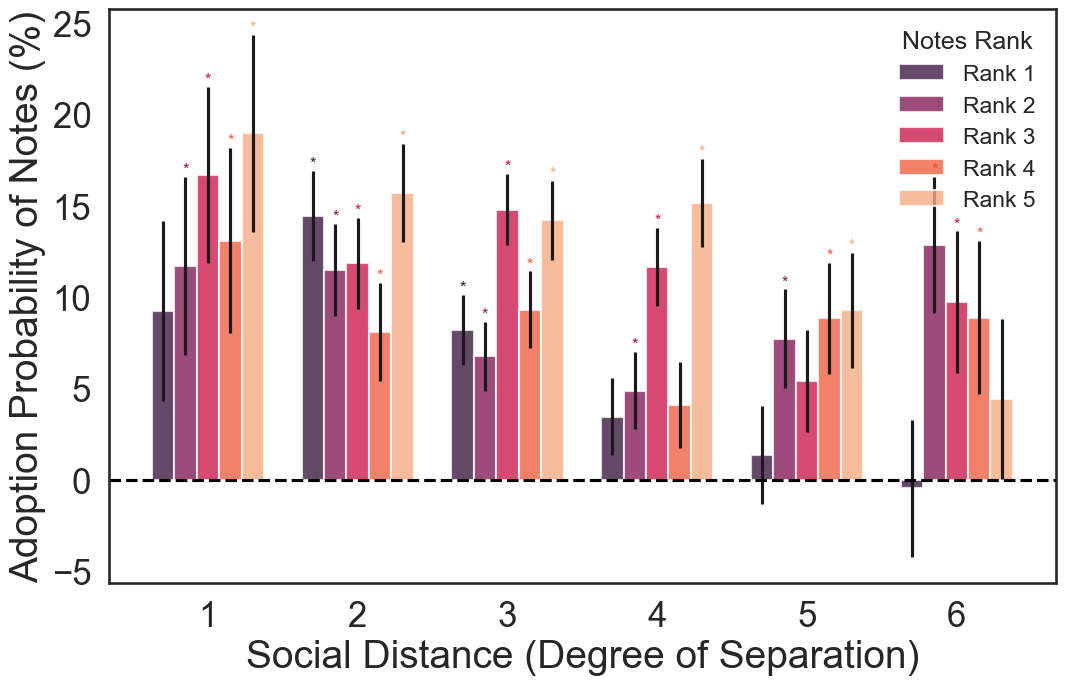


Matched-null quality: full=94%, overlap=5%, any=1%, none=0%
Real connected pairs sharing a house with the focal: 33.9%
Bars marked * differ from the homophily+house-matched null at |z| >= 1.96 (p < 0.05).

Relative change in adoption probability (%) - averaged across top-5 note ranks:
Distance	Mean_Rel_Change	Mean_Std_Error	N_obs
1		+13.94		5.01		1748
2		+12.32		2.57		6977
3		+10.65		2.01		11748
4		+7.85		2.22		10429
5		+6.52		2.87		6417
6		+7.08		3.98		3582

The null now controls for pre-existing style similarity AND shared house/brand, so a positive residual = social contagion beyond homophily and house effects. At d=1 this is the matched 4g dyadic test; the signal decays toward zero with distance.


In [4]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
from utils.utils import parse_perfumer, clean_perfumer_artifacts, parse_notes, build_network_nx, calculate_top_n_labels

def main():
    N_RANKS    = 5
    MAX_D      = 6
    MIN_WORKS  = 2
    MIN_SOURCE = 2
    N_SIM      = 5000
    np.random.seed(42)

    df = pd.read_csv("../dataset/Fragrantica.csv")
    df = df.dropna(subset=['year']).copy()
    df['year'] = df['year'].astype(int)
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumer)
    df['parsed_perfumers'] = [clean_perfumer_artifacts(ps, hs)
                              for ps, hs in zip(df['parsed_perfumers'], df['brand'])]
    df['parsed_labels'] = df['notes'].apply(parse_notes)

    timeline = defaultdict(list)
    house_timeline = defaultdict(list)
    collaborators = defaultdict(set)
    pair_year = {}
    pair_joint = defaultdict(set)
    for _, row in df.iterrows():
        perfs = row['parsed_perfumers']
        if not perfs:
            continue
        y, pid, labs, h = row['year'], row['id'], row['parsed_labels'], row.get('brand')
        if labs:
            for p in perfs:
                timeline[p].append((y, labs, pid))
        if isinstance(h, str) and h.strip():
            for p in perfs:
                house_timeline[p].append((y, h.strip()))
        uniq = set(perfs)
        if len(uniq) >= 2:
            for a, b in combinations(uniq, 2):
                collaborators[a].add(b); collaborators[b].add(a)
                key = frozenset((a, b)); pair_joint[key].add(pid)
                if key not in pair_year or y < pair_year[key]:
                    pair_year[key] = y
    first_year = {p: min(yy for yy, _, _ in w) for p, w in timeline.items()}

    rows = [{'perfumer': p, 'note': a, 'count': 1}
            for p, works in timeline.items() for _, labs, _ in works for a in labs]
    labeled = set(calculate_top_n_labels(pd.DataFrame(rows), 'note', n=N_RANKS)['perfumer'].unique())
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda xs: [p for p in xs if p in labeled])
    G = build_network_nx(df[df['filtered_perfumers'].apply(len) > 1].copy())
    nodes = list(G.nodes()); n = len(nodes); idx = {p: i for i, p in enumerate(nodes)}
    if n == 0:
        print("Network is empty."); return

    INF = np.inf
    W = np.full((n, n), INF)                              # W[c, f] = first co-creation year of edge (c, f)
    for u, v in G.edges():
        t = pair_year[frozenset((u, v))]
        W[idx[u], idx[v]] = t; W[idx[v], idx[u]] = t
    edges_dir = [(idx[u], idx[v], pair_year[frozenset((u, v))]) for u, v in G.edges()]
    edges_dir += [(v, u, t) for (u, v, t) in list(edges_dir)]   # traverse each edge both ways
    # CAUSAL constraint: earliest-arrival TIME-RESPECTING reachability. A source reaches a focal
    # only along a collaboration chain whose years are NON-DECREASING toward the focal. ARR[s, f]
    # = earliest year a chain of <= k hops carries source s to focal f; HOP = its hop count.
    ARR = W.copy(); np.fill_diagonal(ARR, -INF)           # a source is "available" from the start
    HOP = np.zeros((n, n), np.int16); Tarr = np.full((n, n), INF)
    fin = np.isfinite(ARR) & ~np.eye(n, dtype=bool)
    HOP[fin] = 1; Tarr[fin] = ARR[fin]                    # d = 1 is a single co-creation (symmetric)
    for k in range(2, MAX_D + 1):
        ARR_new = ARR.copy()
        for c, f, t in edges_dir:                         # append edge c->f only if t >= arrival at c
            upd = (ARR[:, c] <= t) & (t < ARR_new[:, f])
            ARR_new[upd, f] = t
        ARR = ARR_new
        newly = (HOP == 0) & np.isfinite(ARR) & ~np.eye(n, dtype=bool)
        HOP[newly] = k; Tarr[newly] = ARR[newly]
    # index as [focal, source] so the loop below (focal A=ii, source B=jj) reads the B -> A chain
    d_final = HOP.T.copy(); T_conn = Tarr.T.copy()

    def topk(works, k):
        agg = Counter()
        for _, labs, _ in works:
            for a in labs:
                agg[a] += 1
        return [a for a, _ in sorted(agg.items(), key=lambda kv: (-kv[1], kv[0]))[:k]]

    def works_before(p, T):
        return [w for w in timeline[p] if w[0] < T]

    def works_after(p, T, exclude_ids):
        return [w for w in timeline[p] if w[0] > T and w[2] not in exclude_ids]

    prior_cache = {}
    def prior_signature(p, T):
        key = (p, T)
        if key not in prior_cache:
            wb = works_before(p, T)
            prior_cache[key] = (topk(wb, N_RANKS), len(wb))
        return prior_cache[key]

    before_cache = {}
    def before_set(p, T):
        key = (p, T)
        if key not in before_cache:
            before_cache[key] = set(topk(works_before(p, T), N_RANKS))
        return before_cache[key]

    sigset_cache = {}
    def sig_set(p, T):
        key = (p, T)
        if key not in sigset_cache:
            sigset_cache[key] = set(prior_signature(p, T)[0])
        return sigset_cache[key]

    houses_cache = {}
    def houses_before(p, T):
        key = (p, T)
        if key not in houses_cache:
            houses_cache[key] = {hh for yy, hh in house_timeline[p] if yy < T}
        return houses_cache[key]

    observations = []
    for ii in range(n):
        for jj in range(n):
            if ii == jj:
                continue
            d = int(d_final[ii, jj])
            if not (1 <= d <= MAX_D):
                continue
            T = T_conn[ii, jj]
            A, B = nodes[ii], nodes[jj]
            joint = pair_joint.get(frozenset((A, B)), set())
            fb = works_before(A, T)
            fa = works_after(A, T, joint)
            if len(fb) < MIN_WORKS or len(fa) < MIN_WORKS:
                continue
            sig, sn = prior_signature(B, T)
            if sn < MIN_SOURCE or not sig:
                continue
            A_before = before_set(A, T); houses_A = houses_before(A, T)
            observations.append({
                'd': d, 'T': T, 'focal': A,
                'before': A_before,
                'after': set(topk(fa, N_RANKS)),
                'sig': sig,
                'm': len(sig_set(B, T) & A_before),
                'h': len(houses_before(B, T) & houses_A) > 0,
            })
    n_obs = len(observations)
    print(f"Network nodes: {n} | usable ordered observations (d<=6): {n_obs}")
    if n_obs == 0:
        print("No observations meet the data requirements."); return

    def aggregate(sig_of):
        num = {r: {d: 0 for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
        den = {r: {d: 0 for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
        for o in observations:
            sig = sig_of(o)
            if not sig:
                continue
            d, bset, aset = o['d'], o['before'], o['after']
            for r in range(1, N_RANKS + 1):
                if len(sig) < r:
                    continue
                lab = sig[r - 1]
                if lab in bset:
                    continue
                den[r][d] += 1
                if lab in aset:
                    num[r][d] += 1
        return num, den

    onum, oden = aggregate(lambda o: o['sig'])
    obs_rate = {r: {d: (onum[r][d] / oden[r][d] if oden[r][d] else 0.0)
                    for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}

    pool = [c for c in collaborators if c in timeline]
    pool_by_T = {}
    for T in {o['T'] for o in observations}:
        pool_by_T[T] = [c for c in pool
                        if first_year.get(c, T) < T and prior_signature(c, T)[1] >= MIN_SOURCE
                        and prior_signature(c, T)[0]]
    match_stats = Counter()
    def matched_fake_source(o):
        T, A, A_before, m_t, h_t = o['T'], o['focal'], o['before'], o['m'], o['h']
        houses_A = houses_before(A, T); bad = collaborators[A]; cands = pool_by_T.get(T, [])
        if not cands:
            match_stats['none'] += 1; return None
        nC = len(cands)
        for _ in range(40):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(sig_set(c, T) & A_before) == m_t and (len(houses_before(c, T) & houses_A) > 0) == h_t:
                match_stats['full'] += 1; return prior_signature(c, T)[0]
        for _ in range(20):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(sig_set(c, T) & A_before) == m_t:
                match_stats['overlap'] += 1; return prior_signature(c, T)[0]
        for _ in range(10):
            c = cands[np.random.randint(nC)]
            if c != A and c not in bad:
                match_stats['any'] += 1; return prior_signature(c, T)[0]
        match_stats['none'] += 1; return None

    null = {r: {d: [] for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
    for _ in range(N_SIM):
        nnum, nden = aggregate(matched_fake_source)
        for r in range(1, N_RANKS + 1):
            for d in range(1, MAX_D + 1):
                null[r][d].append(nnum[r][d] / nden[r][d] if nden[r][d] else 0.0)

    relative_increase     = {r: {} for r in range(1, N_RANKS + 1)}
    relative_increase_err = {r: {} for r in range(1, N_RANKS + 1)}
    zscore                = {r: {} for r in range(1, N_RANKS + 1)}
    for r in range(1, N_RANKS + 1):
        for d in range(1, MAX_D + 1):
            mu = float(np.mean(null[r][d])); sd = float(np.std(null[r][d], ddof=1))
            if mu > 0:
                relative_increase[r][d] = (obs_rate[r][d] - mu) / mu * 100.0
                relative_increase_err[r][d] = sd / mu * 100.0
            else:
                relative_increase[r][d] = 0.0
                relative_increase_err[r][d] = 0.0
            zscore[r][d] = ((obs_rate[r][d] - mu) / sd) if sd > 0 else 0.0

    sns.set_style("white")
    palette = sns.color_palette("rocket", N_RANKS)
    distances = np.arange(1, MAX_D + 1)
    width = 0.15
    offset = -(N_RANKS // 2) * width
    plt.figure(figsize=(11, 7.2))
    for i, rank in enumerate(range(1, N_RANKS + 1)):
        ri_vals = [relative_increase[rank][d] for d in range(1, MAX_D + 1)]
        ri_errs = [relative_increase_err[rank][d] for d in range(1, MAX_D + 1)]
        x_pos = distances + offset + i * width
        plt.bar(x_pos, ri_vals, yerr=ri_errs, width=width, color=palette[i], alpha=0.8, label=f"Rank {rank}")
        for j, d in enumerate(range(1, MAX_D + 1)):
            if abs(zscore[rank][d]) >= 1.96:
                v, e = ri_vals[j], ri_errs[j]
                yy = (v + e) if v >= 0 else (v - e)
                plt.text(x_pos[j], yy, '*', ha='center',
                         va='bottom' if v >= 0 else 'top', fontsize=12, color=palette[i])
    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=28)
    plt.ylabel("Adoption Probability of Notes (%)", fontsize=28)
    plt.legend(title="Notes Rank", frameon=False,loc='upper right')
    plt.xticks(fontsize=25); plt.yticks(fontsize=25)
    plt.tight_layout()
    plt.savefig("../output/Figure_4D.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    tot = sum(match_stats.values()) or 1
    print(f"\nMatched-null quality: " +
          ", ".join(f"{k}={100*match_stats[k]/tot:.0f}%" for k in ['full', 'overlap', 'any', 'none']))
    print(f"Real connected pairs sharing a house with the focal: "
          f"{100*np.mean([o['h'] for o in observations]):.1f}%")
    print("Bars marked * differ from the homophily+house-matched null at |z| >= 1.96 (p < 0.05).")
    print("\nRelative change in adoption probability (%) - averaged across top-5 note ranks:")
    print("Distance\tMean_Rel_Change\tMean_Std_Error\tN_obs")
    nobs_by_d = Counter(o['d'] for o in observations)
    for d in range(1, MAX_D + 1):
        mr = np.mean([relative_increase[r][d] for r in range(1, N_RANKS + 1)])
        me = np.mean([relative_increase_err[r][d] for r in range(1, N_RANKS + 1)])
        print(f"{d}\t\t{mr:+.2f}\t\t{me:.2f}\t\t{nobs_by_d[d]}")
    print("\nThe null now controls for pre-existing style similarity AND shared house/brand, so a "
          "positive residual = social contagion beyond homophily and house effects. At d=1 this is "
          "the matched 4g dyadic test; the signal decays toward zero with distance.")

if __name__ == "__main__":
    main()

### Figure 4E: Accord Contagion Across Social Distance (Matched Null)

Accord counterpart of Figure 4D, with the same event-anchored before/after design and homophily- and house-matched null. Controlling for these covariates shrinks the d=1 signal by about 40% relative to a random null, but a significant residual remains at short distances and decays with distance. Bars marked `*` differ from the null at |z| >= 1.96.

Network nodes: 501 | usable ordered observations (d<=6): 40901


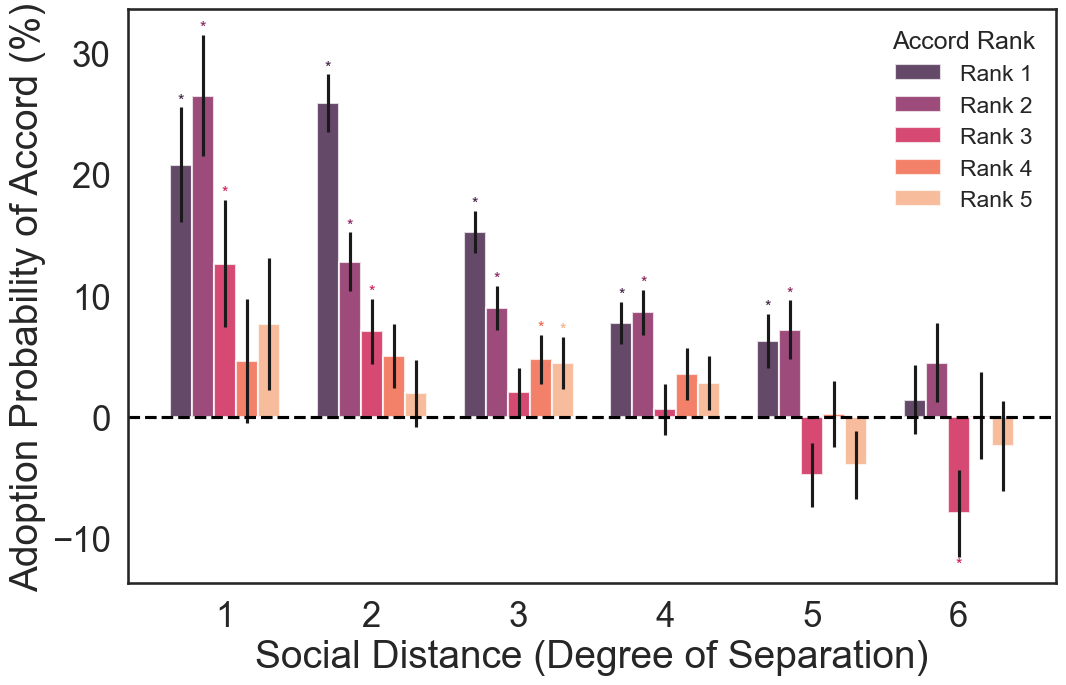


Matched-null quality: full=95%, overlap=4%, any=1%, none=0%
Real connected pairs sharing a house with the focal: 33.9%
Bars marked * differ from the homophily+house-matched null at |z| >= 1.96 (p < 0.05).

Relative change in adoption probability (%) - averaged across top-5 accord ranks:
Distance	Mean_Rel_Change	Mean_Std_Error	N_obs
1		+14.46		5.10		1748
2		+10.53		2.57		6977
3		+7.09		1.94		11748
4		+4.66		2.02		10429
5		+0.98		2.55		6417
6		-0.89		3.40		3582

The null now controls for pre-existing style similarity AND shared house/brand, so a positive residual = social contagion beyond homophily and house effects. At d=1 this is the matched 4f/4g dyadic test; the signal decays toward zero with distance.


In [5]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
from utils.utils import parse_perfumer, clean_perfumer_artifacts, parse_accords, build_network_nx, calculate_top_n_labels

def main():
    N_RANKS    = 5
    MAX_D      = 6
    MIN_WORKS  = 2
    MIN_SOURCE = 2
    N_SIM      = 5000
    np.random.seed(42)

    df = pd.read_csv("../dataset/Fragrantica.csv")
    df = df.dropna(subset=['year']).copy()
    df['year'] = df['year'].astype(int)
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumer)
    df['parsed_perfumers'] = [clean_perfumer_artifacts(ps, hs)
                              for ps, hs in zip(df['parsed_perfumers'], df['brand'])]
    df['parsed_labels'] = df['accords'].apply(parse_accords)

    timeline = defaultdict(list)
    house_timeline = defaultdict(list)
    collaborators = defaultdict(set)
    pair_year = {}
    pair_joint = defaultdict(set)
    for _, row in df.iterrows():
        perfs = row['parsed_perfumers']
        if not perfs:
            continue
        y, pid, labs, h = row['year'], row['id'], row['parsed_labels'], row.get('brand')
        if labs:
            for p in perfs:
                timeline[p].append((y, labs, pid))
        if isinstance(h, str) and h.strip():
            for p in perfs:
                house_timeline[p].append((y, h.strip()))
        uniq = set(perfs)
        if len(uniq) >= 2:
            for a, b in combinations(uniq, 2):
                collaborators[a].add(b); collaborators[b].add(a)
                key = frozenset((a, b)); pair_joint[key].add(pid)
                if key not in pair_year or y < pair_year[key]:
                    pair_year[key] = y
    first_year = {p: min(yy for yy, _, _ in w) for p, w in timeline.items()}

    rows = [{'perfumer': p, 'accord': a, 'count': 1}
            for p, works in timeline.items() for _, labs, _ in works for a in labs]
    labeled = set(calculate_top_n_labels(pd.DataFrame(rows), 'accord', n=N_RANKS)['perfumer'].unique())
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda xs: [p for p in xs if p in labeled])
    G = build_network_nx(df[df['filtered_perfumers'].apply(len) > 1].copy())
    nodes = list(G.nodes()); n = len(nodes); idx = {p: i for i, p in enumerate(nodes)}
    if n == 0:
        print("Network is empty."); return

    INF = np.inf
    W = np.full((n, n), INF)                              # W[c, f] = first co-creation year of edge (c, f)
    for u, v in G.edges():
        t = pair_year[frozenset((u, v))]
        W[idx[u], idx[v]] = t; W[idx[v], idx[u]] = t
    edges_dir = [(idx[u], idx[v], pair_year[frozenset((u, v))]) for u, v in G.edges()]
    edges_dir += [(v, u, t) for (u, v, t) in list(edges_dir)]   # traverse each edge both ways
    # CAUSAL constraint: earliest-arrival TIME-RESPECTING reachability. A source reaches a focal
    # only along a collaboration chain whose years are NON-DECREASING toward the focal. ARR[s, f]
    # = earliest year a chain of <= k hops carries source s to focal f; HOP = its hop count.
    ARR = W.copy(); np.fill_diagonal(ARR, -INF)           # a source is "available" from the start
    HOP = np.zeros((n, n), np.int16); Tarr = np.full((n, n), INF)
    fin = np.isfinite(ARR) & ~np.eye(n, dtype=bool)
    HOP[fin] = 1; Tarr[fin] = ARR[fin]                    # d = 1 is a single co-creation (symmetric)
    for k in range(2, MAX_D + 1):
        ARR_new = ARR.copy()
        for c, f, t in edges_dir:                         # append edge c->f only if t >= arrival at c
            upd = (ARR[:, c] <= t) & (t < ARR_new[:, f])
            ARR_new[upd, f] = t
        ARR = ARR_new
        newly = (HOP == 0) & np.isfinite(ARR) & ~np.eye(n, dtype=bool)
        HOP[newly] = k; Tarr[newly] = ARR[newly]
    # index as [focal, source] so the loop below (focal A=ii, source B=jj) reads the B -> A chain
    d_final = HOP.T.copy(); T_conn = Tarr.T.copy()

    def topk(works, k):
        agg = Counter()
        for _, labs, _ in works:
            for a in labs:
                agg[a] += 1
        return [a for a, _ in sorted(agg.items(), key=lambda kv: (-kv[1], kv[0]))[:k]]

    def works_before(p, T):
        return [w for w in timeline[p] if w[0] < T]

    def works_after(p, T, exclude_ids):
        return [w for w in timeline[p] if w[0] > T and w[2] not in exclude_ids]

    prior_cache = {}
    def prior_signature(p, T):
        key = (p, T)
        if key not in prior_cache:
            wb = works_before(p, T)
            prior_cache[key] = (topk(wb, N_RANKS), len(wb))
        return prior_cache[key]

    before_cache = {}
    def before_set(p, T):
        key = (p, T)
        if key not in before_cache:
            before_cache[key] = set(topk(works_before(p, T), N_RANKS))
        return before_cache[key]

    sigset_cache = {}
    def sig_set(p, T):
        key = (p, T)
        if key not in sigset_cache:
            sigset_cache[key] = set(prior_signature(p, T)[0])
        return sigset_cache[key]

    houses_cache = {}
    def houses_before(p, T):
        key = (p, T)
        if key not in houses_cache:
            houses_cache[key] = {hh for yy, hh in house_timeline[p] if yy < T}
        return houses_cache[key]

    observations = []
    for ii in range(n):
        for jj in range(n):
            if ii == jj:
                continue
            d = int(d_final[ii, jj])
            if not (1 <= d <= MAX_D):
                continue
            T = T_conn[ii, jj]
            A, B = nodes[ii], nodes[jj]
            joint = pair_joint.get(frozenset((A, B)), set())
            fb = works_before(A, T)
            fa = works_after(A, T, joint)
            if len(fb) < MIN_WORKS or len(fa) < MIN_WORKS:
                continue
            sig, sn = prior_signature(B, T)
            if sn < MIN_SOURCE or not sig:
                continue
            A_before = before_set(A, T); houses_A = houses_before(A, T)
            observations.append({
                'd': d, 'T': T, 'focal': A,
                'before': A_before,
                'after': set(topk(fa, N_RANKS)),
                'sig': sig,
                'm': len(sig_set(B, T) & A_before),
                'h': len(houses_before(B, T) & houses_A) > 0,
            })
    n_obs = len(observations)
    print(f"Network nodes: {n} | usable ordered observations (d<=6): {n_obs}")
    if n_obs == 0:
        print("No observations meet the data requirements."); return

    def aggregate(sig_of):
        num = {r: {d: 0 for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
        den = {r: {d: 0 for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
        for o in observations:
            sig = sig_of(o)
            if not sig:
                continue
            d, bset, aset = o['d'], o['before'], o['after']
            for r in range(1, N_RANKS + 1):
                if len(sig) < r:
                    continue
                lab = sig[r - 1]
                if lab in bset:
                    continue
                den[r][d] += 1
                if lab in aset:
                    num[r][d] += 1
        return num, den

    onum, oden = aggregate(lambda o: o['sig'])
    obs_rate = {r: {d: (onum[r][d] / oden[r][d] if oden[r][d] else 0.0)
                    for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}

    pool = [c for c in collaborators if c in timeline]
    pool_by_T = {}
    for T in {o['T'] for o in observations}:
        pool_by_T[T] = [c for c in pool
                        if first_year.get(c, T) < T and prior_signature(c, T)[1] >= MIN_SOURCE
                        and prior_signature(c, T)[0]]
    match_stats = Counter()
    def matched_fake_source(o):
        T, A, A_before, m_t, h_t = o['T'], o['focal'], o['before'], o['m'], o['h']
        houses_A = houses_before(A, T); bad = collaborators[A]; cands = pool_by_T.get(T, [])
        if not cands:
            match_stats['none'] += 1; return None
        nC = len(cands)
        for _ in range(40):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(sig_set(c, T) & A_before) == m_t and (len(houses_before(c, T) & houses_A) > 0) == h_t:
                match_stats['full'] += 1; return prior_signature(c, T)[0]
        for _ in range(20):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(sig_set(c, T) & A_before) == m_t:
                match_stats['overlap'] += 1; return prior_signature(c, T)[0]
        for _ in range(10):
            c = cands[np.random.randint(nC)]
            if c != A and c not in bad:
                match_stats['any'] += 1; return prior_signature(c, T)[0]
        match_stats['none'] += 1; return None

    null = {r: {d: [] for d in range(1, MAX_D + 1)} for r in range(1, N_RANKS + 1)}
    for _ in range(N_SIM):
        nnum, nden = aggregate(matched_fake_source)
        for r in range(1, N_RANKS + 1):
            for d in range(1, MAX_D + 1):
                null[r][d].append(nnum[r][d] / nden[r][d] if nden[r][d] else 0.0)

    relative_increase     = {r: {} for r in range(1, N_RANKS + 1)}
    relative_increase_err = {r: {} for r in range(1, N_RANKS + 1)}
    zscore                = {r: {} for r in range(1, N_RANKS + 1)}
    for r in range(1, N_RANKS + 1):
        for d in range(1, MAX_D + 1):
            mu = float(np.mean(null[r][d])); sd = float(np.std(null[r][d], ddof=1))
            if mu > 0:
                relative_increase[r][d] = (obs_rate[r][d] - mu) / mu * 100.0
                relative_increase_err[r][d] = sd / mu * 100.0
            else:
                relative_increase[r][d] = 0.0
                relative_increase_err[r][d] = 0.0
            zscore[r][d] = ((obs_rate[r][d] - mu) / sd) if sd > 0 else 0.0

    sns.set_style("white")
    palette = sns.color_palette("rocket", N_RANKS)
    distances = np.arange(1, MAX_D + 1)
    width = 0.15
    offset = -(N_RANKS // 2) * width
    plt.figure(figsize=(11, 7.2))
    for i, rank in enumerate(range(1, N_RANKS + 1)):
        ri_vals = [relative_increase[rank][d] for d in range(1, MAX_D + 1)]
        ri_errs = [relative_increase_err[rank][d] for d in range(1, MAX_D + 1)]
        x_pos = distances + offset + i * width
        plt.bar(x_pos, ri_vals, yerr=ri_errs, width=width, color=palette[i], alpha=0.8, label=f"Rank {rank}")
        for j, d in enumerate(range(1, MAX_D + 1)):
            if abs(zscore[rank][d]) >= 1.96:
                v, e = ri_vals[j], ri_errs[j]
                yy = (v + e) if v >= 0 else (v - e)
                plt.text(x_pos[j], yy, '*', ha='center',
                         va='bottom' if v >= 0 else 'top', fontsize=12, color=palette[i])
    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=28)
    plt.ylabel("Adoption Probability of Accord (%)", fontsize=28)
    plt.legend(title="Accord Rank", frameon=False,loc='upper right')
    plt.xticks(fontsize=25); plt.yticks(fontsize=25)
    plt.tight_layout()
    plt.savefig("../output/Figure_4E.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    tot = sum(match_stats.values()) or 1
    print(f"\nMatched-null quality: " +
          ", ".join(f"{k}={100*match_stats[k]/tot:.0f}%" for k in ['full', 'overlap', 'any', 'none']))
    print(f"Real connected pairs sharing a house with the focal: "
          f"{100*np.mean([o['h'] for o in observations]):.1f}%")
    print("Bars marked * differ from the homophily+house-matched null at |z| >= 1.96 (p < 0.05).")
    print("\nRelative change in adoption probability (%) - averaged across top-5 accord ranks:")
    print("Distance\tMean_Rel_Change\tMean_Std_Error\tN_obs")
    nobs_by_d = Counter(o['d'] for o in observations)
    for d in range(1, MAX_D + 1):
        mr = np.mean([relative_increase[r][d] for r in range(1, N_RANKS + 1)])
        me = np.mean([relative_increase_err[r][d] for r in range(1, N_RANKS + 1)])
        print(f"{d}\t\t{mr:+.2f}\t\t{me:.2f}\t\t{nobs_by_d[d]}")
    print("\nThe null now controls for pre-existing style similarity AND shared house/brand, so a "
          "positive residual = social contagion beyond homophily and house effects. At d=1 this is "
          "the matched 4f/4g dyadic test; the signal decays toward zero with distance.")

if __name__ == "__main__":
    main()

### Figure 4F: Network Centrality vs Complexity & Novelty

Relates each perfumer's collaboration-network centrality (degree, eigenvector) to their mean Perfume Complexity and Perfume Novelty (markers = mean, error bars = +/-1 SD; well-documented perfumes, `Total_votes >= 286`).

loaded 76632 perfumes
using saved pair/triple surprisal
network: 502 perfumers, 1453 collaborations


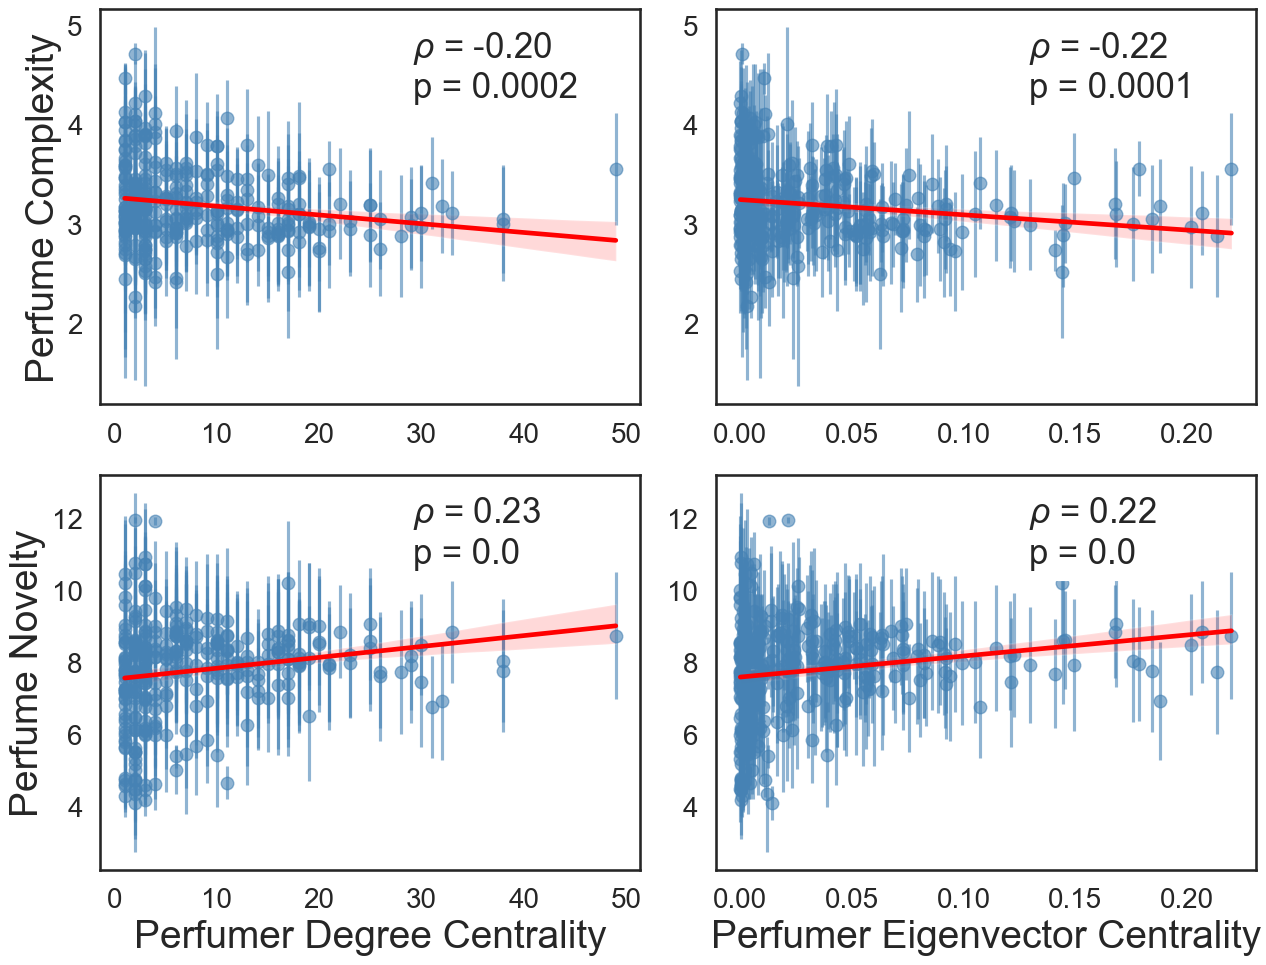

In [12]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr
from utils.utils import parse_perfumer, clean_perfumer_artifacts, parse_notes, parse_notes_weighted, build_network_nx

W_MIN = 286

def perfume_novelty(df):
    """Vote-weighted pair & triple note-co-occurrence surprisal vs all earlier perfumes
    (Fig 2B), on Total_votes >= W_MIN perfumes, with add-one (Laplace) smoothing so
    genuinely novel combinations are included. Returns [id, pair_surprisal, triple_surprisal]."""
    w = df.dropna(subset=['year', 'notes', 'Total_votes']).copy()
    w['Total_votes'] = pd.to_numeric(w['Total_votes'], errors='coerce')
    w = w.dropna(subset=['Total_votes'])
    w = w[(w['Total_votes'] >= W_MIN) & (w['year'].between(1900, 2024))].copy()
    w['_w'] = w['notes'].apply(parse_notes_weighted)
    w = w[w['_w'].map(len) > 0].sort_values('year').reset_index(drop=True)
    pc, tc, npast, pps, tps = {}, {}, 0, [], []
    for wt in w['_w']:
        notes = sorted(wt)
        prs, trs = list(combinations(notes, 2)), list(combinations(notes, 3))
        num = den = 0.0
        if npast > 0:
            for i, j in prs:
                wij = (wt[i] + wt[j]) / 2
                num += wij * (-np.log2((pc.get((i, j), 0) + 1) / (npast + 2))); den += wij
        pps.append(num / den if den > 0 else np.nan)
        num = den = 0.0
        if npast > 0:
            for i, j, k in trs:
                wijk = (wt[i] + wt[j] + wt[k]) / 3
                num += wijk * (-np.log2((tc.get((i, j, k), 0) + 1) / (npast + 2))); den += wijk
        tps.append(num / den if den > 0 else np.nan)
        for i, j in prs: pc[(i, j)] = pc.get((i, j), 0) + 1
        for i, j, k in trs: tc[(i, j, k)] = tc.get((i, j, k), 0) + 1
        npast += 1
    w['pair_surprisal'] = pps; w['triple_surprisal'] = tps
    return w[['id', 'pair_surprisal', 'triple_surprisal']]

def main():
    need = {'id', 'perfumer', 'brand', 'year', 'notes', 'Total_votes',
            'Perfume_Complexity', 'pair_surprisal', 'triple_surprisal'}
    df = pd.read_csv("../dataset/Fragrantica_with_metrics.csv", usecols=lambda c: c in need)
    print(f"loaded {len(df)} perfumes")
    df['parsed_perfumers'] = [clean_perfumer_artifacts(parse_perfumer(p), h)
                              for p, h in zip(df['perfumer'], df['brand'])]

    if 'pair_surprisal' in df.columns and df['pair_surprisal'].notna().any():
        print("using saved pair/triple surprisal")
    else:
        print("computing Perfume Novelty in-cell (~seconds)...")
        nov = perfume_novelty(df)
        df = df.drop(columns=['pair_surprisal', 'triple_surprisal'], errors='ignore').merge(nov, on='id', how='left')
    df['novelty'] = df[['pair_surprisal', 'triple_surprisal']].mean(axis=1)
    ws = pd.to_numeric(df['Total_votes'], errors='coerce')
    df['cx'] = df['Perfume_Complexity'].where(ws >= W_MIN)

    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p and p.strip()])
    G = build_network_nx(df[df['filtered_perfumers'].apply(len) > 1].copy())
    if G.number_of_nodes() == 0:
        print("No connected network found."); return
    try:
        ec = nx.eigenvector_centrality_numpy(G)
    except Exception:
        ec = nx.eigenvector_centrality(G, max_iter=2000)
    deg = dict(G.degree())
    centrality_df = pd.DataFrame({'perfumer': list(G.nodes()),
                                  'eigenvector': [ec[n] for n in G.nodes()],
                                  'degree': [deg[n] for n in G.nodes()]})
    print(f"network: {G.number_of_nodes()} perfumers, {G.number_of_edges()} collaborations")

    METRICS = [('cx', 'Perfume Complexity'), ('novelty', 'Perfume Novelty')]
    ex = (df[['parsed_perfumers', 'cx', 'novelty']]
          .explode('parsed_perfumers').rename(columns={'parsed_perfumers': 'perfumer'}))
    ex = ex[ex['perfumer'].notna() & (ex['perfumer'].astype(str).str.strip() != '')]
    agg = ex.groupby('perfumer').agg(cx_mean=('cx', 'mean'), cx_std=('cx', 'std'),
                                     novelty_mean=('novelty', 'mean'), novelty_std=('novelty', 'std')).reset_index()
    merged = pd.merge(centrality_df, agg, on='perfumer', how='inner')

    sns.set_style("white")
    fig, axs = plt.subplots(nrows=len(METRICS), ncols=2, figsize=(13, 10))

    def plot_reg(ax, xvals, yvals, yerrs, x_label, y_label):
        m = pd.DataFrame({'x': xvals.values, 'y': yvals.values, 'e': yerrs.values}).dropna()
        ax.errorbar(m['x'], m['y'], yerr=m['e'], fmt='o', alpha=0.6, color='steelblue', zorder=1)
        sns.regplot(x='x', y='y', data=m, ci=95, scatter=False, color='red', ax=ax, line_kws={'zorder': 2})
        rho, pval = spearmanr(m['x'], m['y'])
        ax.text(0.58, 0.95, f"$\\it{{\\rho}}$ = {rho:.2f}\np = {round(float(f'{pval:.2g}'), 4)}",
                transform=ax.transAxes, fontsize=25, verticalalignment='top',
                bbox=dict(facecolor='white', alpha=1, boxstyle='round'))
        ax.set_xlabel(x_label, fontsize=28); ax.set_ylabel(y_label, fontsize=28)
        ax.tick_params(labelsize=20); ax.grid(False)

    last = len(METRICS) - 1
    for r, (col, lab) in enumerate(METRICS):
        plot_reg(axs[r, 0], merged['degree'], merged[f'{col}_mean'], merged[f'{col}_std'],
                 "Perfumer Degree Centrality" if r == last else "", lab)
        plot_reg(axs[r, 1], merged['eigenvector'], merged[f'{col}_mean'], merged[f'{col}_std'],
                 "Perfumer Eigenvector Centrality" if r == last else "", "")

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig("../output/Figure_4F.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main()

### Figure 4G: Disruption (CD5) of Collaborative vs Solo Perfumers

Per-perfumer mean CD5 disruption index, split by whether they ever collaborated (on a >=2-perfumer perfume) vs always worked solo (each with >=3 CD5-defined perfumes). Notched box plots (notch = 95% CI of the median) with a two-sided Mann-Whitney U test. 

Collaborative perfumers: 455 (median CD5 +0.028) | Solo: 302 (median +0.050) | Mann-Whitney p=1.38e-05


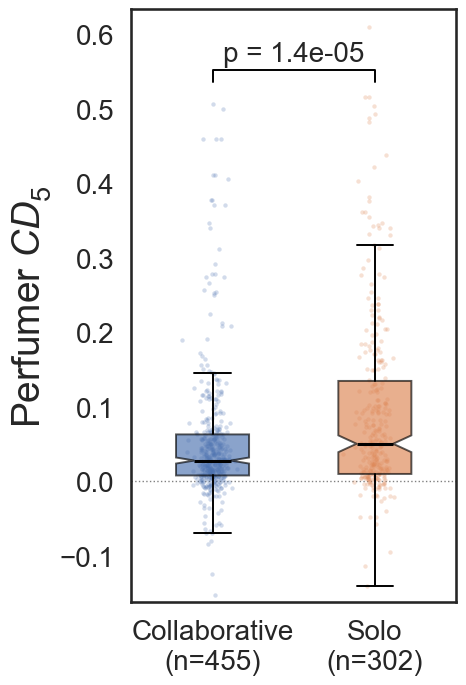

In [7]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from utils.utils import parse_perfumer, clean_perfumer_artifacts, compute_cd_indices

MIN_PERF = 3

def main():
    df = pd.read_csv("../dataset/Fragrantica.csv",
                     usecols=['id', 'year', 'perfumer', 'brand', 'this_perfume_reminds_ids'])
    df['parsed_perfumers'] = [clean_perfumer_artifacts(parse_perfumer(p), h)
                              for p, h in zip(df['perfumer'], df['brand'])]
    df = df.merge(compute_cd_indices(df, windows=(5,)), on='id', how='left')

    collaborators = set()
    for pp in df['parsed_perfumers']:
        if len(set(pp)) >= 2:
            collaborators.update(pp)

    recs = [{'perfumer': p, 'cd5': c}
            for pp, c in zip(df['parsed_perfumers'], df['cd5']) if pd.notna(c) for p in set(pp)]
    per = (pd.DataFrame(recs).groupby('perfumer')['cd5']
           .agg(cd5='mean', n='count').reset_index())
    per = per[per['n'] >= MIN_PERF].copy()
    per['group'] = np.where(per['perfumer'].isin(collaborators), 'Collaborative', 'Solo')

    collab = per.loc[per['group'] == 'Collaborative', 'cd5'].values
    solo = per.loc[per['group'] == 'Solo', 'cd5'].values
    U, p = mannwhitneyu(collab, solo, alternative='two-sided')
    print(f"Collaborative perfumers: {len(collab)} (median CD5 {np.median(collab):+.3f}) | "
          f"Solo: {len(solo)} (median {np.median(solo):+.3f}) | Mann-Whitney p={p:.2e}")

    sns.set_style("white"); sns.set_context("talk")
    colors = {'Collaborative': '#4C72B0', 'Solo': '#DD8452'}
    groups = ['Collaborative', 'Solo']
    data = [collab, solo]
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(5, 7.2))

    for i, (g, vals) in enumerate(zip(groups, data), start=1):
        ax.scatter(rng.normal(i, 0.05, len(vals)), vals, s=10, alpha=0.25,
                   color=colors[g], zorder=1, linewidths=0)
    bp = ax.boxplot(data, notch=True, widths=0.45, patch_artist=True, showfliers=False,
                    positions=[1, 2], zorder=3,
                    medianprops=dict(color='black', lw=2.2),
                    whiskerprops=dict(color='black', lw=1.4), capprops=dict(color='black', lw=1.4),
                    boxprops=dict(lw=1.4))
    for patch, g in zip(bp['boxes'], groups):
        patch.set_facecolor(colors[g]); patch.set_alpha(0.65)
    ax.axhline(0, color='gray', ls=':', lw=1, zorder=0)

    allv = np.concatenate(data)
    ylo, yhi = np.quantile(allv, 0.01) - 0.03, np.quantile(allv, 0.99)
    span = yhi - ylo
    ax.set_ylim(ylo, yhi + 0.22 * span)
    yb = yhi + 0.07 * span
    ax.plot([1, 1, 2, 2], [yb, yb + 0.025 * span, yb + 0.025 * span, yb], color='black', lw=1.4)
    stars = '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'n.s.'
    p_txt = f"p = {p:.1e}" if p < 1e-3 else f"p = {p:.3f}"
    ax.text(1.5, yb + 0.03 * span, f"{p_txt}", ha='center', va='bottom', fontsize=20)

    ax.set_xticks([1, 2]); ax.set_xticklabels([f"Collaborative\n(n={len(collab)})", f"Solo\n(n={len(solo)})"], fontsize=20)
    ax.set_ylabel("Perfumer $CD_5$", fontsize=28)
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=20)
    for _sp in ax.spines.values():
        _sp.set_visible(True)
    plt.tight_layout()
    plt.savefig("../output/Figure_4G.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main()

### Figure S11: Smaller Clusters of the Collaboration Network

Figure 4B shows the largest connected component; here the next-largest components are drawn one per panel, titled by rank and size (node size = number of perfumes, edge thickness proportional to perfumes co-created, one color per cluster). There are 16 clusters with >=4 perfumers; the 17 triads and 106 dyads are omitted.

Largest component: 500 perfumers (Fig 4b). Showing 16 clusters with >= 4 perfumers; 17 triads and 106 dyads omitted.


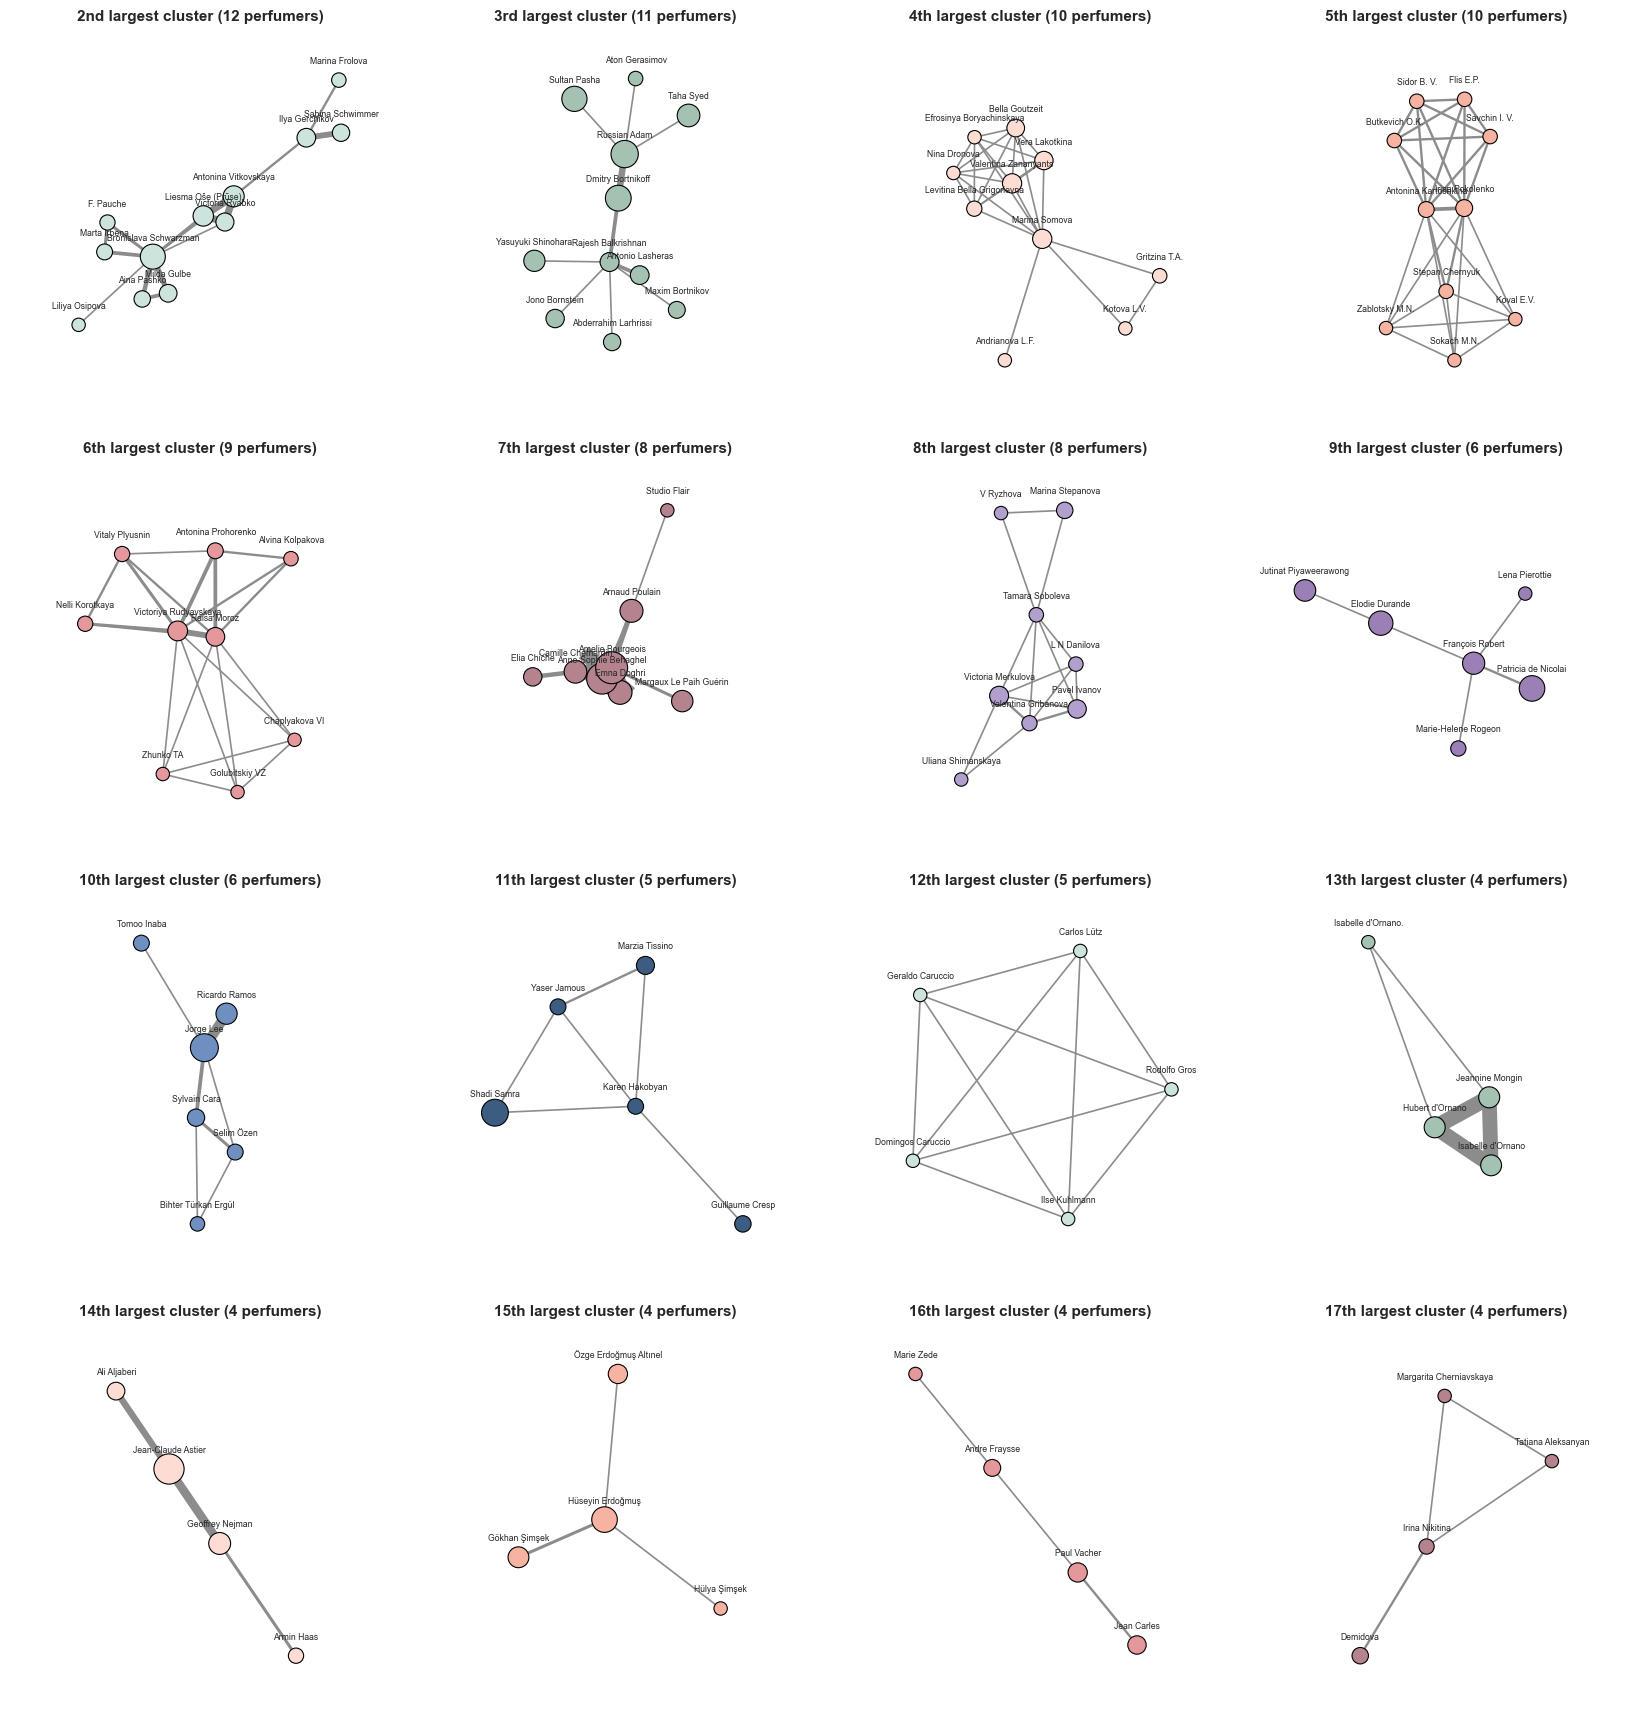

In [8]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
from utils.utils import parse_perfumer, clean_perfumer_artifacts

def main():
    MIN_CLUSTER = 4
    NCOLS       = 4
    PALETTE = ['#CDE4DE', '#A4C2B2', '#FCDCD3', '#F6B3A2', '#E4989C',
               '#B5838D', '#B1A0CE', '#9A80B4', '#6F8FC1', '#3C5D81']
    SIZE_BASE, SIZE_SCALE = 55, 38

    df = pd.read_csv("../dataset/Fragrantica.csv")
    df = df[df['year'] >= 1900]
    df['pp'] = df['perfumer'].apply(parse_perfumer)
    df['pp'] = [clean_perfumer_artifacts(ps, hs) for ps, hs in zip(df['pp'], df['brand'])]
    pcount = Counter(n for lst in df['pp'] for n in lst)
    nsize = lambda n: SIZE_BASE + SIZE_SCALE * np.sqrt(pcount.get(n, 1))

    edge_w = {}
    for perfs in df['pp']:
        for a, b in combinations(sorted(set(perfs)), 2):
            edge_w[(a, b)] = edge_w.get((a, b), 0) + 1
    G = nx.Graph()
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=w)

    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    smaller = [c for c in comps[1:] if len(c) >= MIN_CLUSTER]
    n_dy = sum(len(c) == 2 for c in comps[1:]); n_tri = sum(len(c) == 3 for c in comps[1:])
    print(f"Largest component: {len(comps[0])} perfumers (Fig 4b). "
          f"Showing {len(smaller)} clusters with >= {MIN_CLUSTER} perfumers; "
          f"{n_tri} triads and {n_dy} dyads omitted.")

    def ordinal(k):
        return f"{k}{'th' if 11 <= k % 100 <= 13 else {1: 'st', 2: 'nd', 3: 'rd'}.get(k % 10, 'th')}"

    NROWS = int(np.ceil(len(smaller) / NCOLS))
    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(4.2 * NCOLS, 4.4 * NROWS))
    axes = np.atleast_1d(axes).ravel()

    for i, comp in enumerate(smaller):
        ax = axes[i]
        H = G.subgraph(comp)
        pos = nx.spring_layout(H, k=0.9, iterations=300, weight='weight', seed=7)
        P = np.array([pos[n] for n in H]); P = P - P.mean(0)
        P = P / (np.abs(P).max() + 1e-9)
        pos = {n: P[j] for j, n in enumerate(H)}
        ws = [H[u][v]['weight'] for u, v in H.edges()]
        nx.draw_networkx_edges(H, pos, ax=ax, edge_color='0.55', width=[0.7 + 0.5 * w for w in ws])
        ax.scatter(P[:, 0], P[:, 1], s=[nsize(n) for n in H],
                   c=PALETTE[i % len(PALETTE)], edgecolors='black', linewidths=0.8, zorder=3)
        for j, n in enumerate(H):
            ax.text(P[j, 0], P[j, 1] + 0.10, n, fontsize=6.2, ha='center', va='bottom', zorder=4)
        ax.set_title(f"{ordinal(i + 2)} largest cluster ({len(comp)} perfumers)",
                     fontsize=11, fontweight='bold')
        ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)
        ax.set_aspect('equal'); ax.axis('off')

    for j in range(len(smaller), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig("../output/Figure_S11.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

main()

### Figure S12: Prestige-Biased Style Adoption Between Collaborators

Among direct collaborators (d=1), which perfumer adopts the other's style? Pairs are split by prestige, measured as eigenvector centrality computed within each connected component of the collaboration network as it existed before the collaboration year T (avoiding reverse causation). UP = lower-prestige adopting higher-prestige (low from high), DOWN = the reverse. Both directions show strong contagion vs the matched null (all z > 4). Low-from-high is consistently larger (prestige-biased transmission): the difference is significant for notes by both the matched-null difference test (p approx 0.05) and the raw two-proportion test (p approx 0.002); for accords it is highly significant by the two-proportion test (p < 0.001). Prestige uses a deterministic eigendecomposition and the observations and null draws are canonically ordered, so results are fully reproducible across runs. N_SIM = 5000 

Q: when high- and low-prestige perfumers collaborate (d=1), who adopts whom?

Notes:  low<-high (UP)  P_obs=33.8%  rel_vs_null=+17.8% (z=6.54, n=2083)
        high<-low (DOWN) P_obs=29.4%  rel_vs_null=+12.0% (z=4.23, n=2159)
        low->high stronger?  two-prop p=0.0019  (Cohen's d=0.095)

Accords:  low<-high (UP)  P_obs=36.1%  rel_vs_null=+14.7% (z=5.66, n=1895)
          high<-low (DOWN) P_obs=30.0%  rel_vs_null=+11.5% (z=3.97, n=1946)
          low->high stronger?  two-prop p=0.0001  (Cohen's d=0.131)



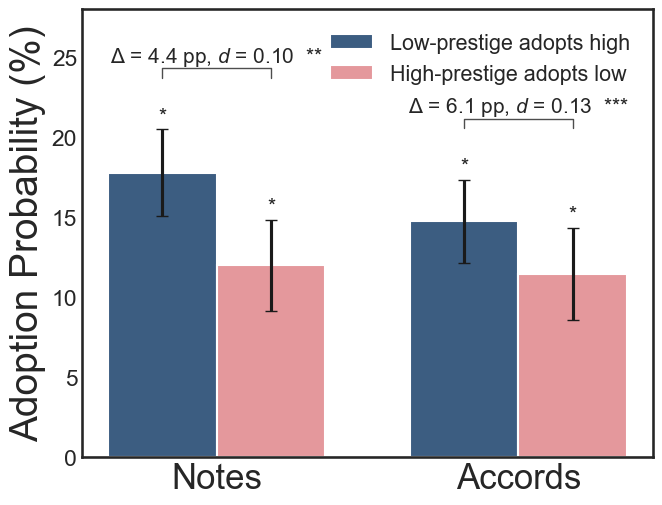

In [9]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
from scipy.stats import norm
from utils.utils import (parse_perfumer, clean_perfumer_artifacts, parse_accords, parse_notes,
                         build_network_nx, calculate_top_n_labels)

def _det_eig_centrality(G):
    """Deterministic eigenvector centrality, computed within each connected component.
    nx.eigenvector_centrality_numpy uses an unseeded ARPACK random start vector, which
    makes prestige (and thus the UP/DOWN split) vary run-to-run; the leading eigenvector
    via a symmetric eigendecomposition (np.linalg.eigh) is exact and reproducible."""
    cent = {}
    for comp in nx.connected_components(G):
        H = G.subgraph(comp); nodes = sorted(H.nodes(), key=str)  # canonical order -> hash-seed-independent eigh
        if len(nodes) == 1:
            cent[nodes[0]] = 0.0
            continue
        A = nx.to_numpy_array(H, nodelist=nodes, weight='weight')
        _, vecs = np.linalg.eigh(A)
        v = np.abs(vecs[:, -1]); nrm = np.linalg.norm(v)
        if nrm > 0:
            v = v / nrm
        for n, x in zip(nodes, v):
            cent[n] = float(x)
    return cent


def prestige_split(mode, N_RANKS=5, MIN_WORKS=2, MIN_SOURCE=2, N_SIM=5000, seed=42):
    """4D/4E adoption test at d=1, split by within-pair prestige rank (UP=low<-high, DOWN=high<-low)."""
    np.random.seed(seed)
    df = pd.read_csv("../dataset/Fragrantica.csv").dropna(subset=['year']).copy()
    df['year'] = df['year'].astype(int)
    if mode == 'note' and 'Total_votes' in df.columns:
        df = df[df['Total_votes'] > 10].copy()
    df['pp'] = df['perfumer'].apply(parse_perfumer)
    df['pp'] = [clean_perfumer_artifacts(ps, hs) for ps, hs in zip(df['pp'], df['brand'])]
    df['lab'] = df['accords'].apply(parse_accords) if mode == 'accord' else df['notes'].apply(parse_notes)

    timeline = defaultdict(list); house_tl = defaultdict(list); collab = defaultdict(set)
    pair_year = {}; pair_joint = defaultdict(set); pair_jyears = defaultdict(list)
    for _, row in df.iterrows():
        perfs = row['pp']
        if not perfs:
            continue
        y, pid, labs, h = row['year'], row['id'], row['lab'], row.get('brand')
        if labs:
            for p in perfs:
                timeline[p].append((y, labs, pid))
        if isinstance(h, str) and h.strip():
            for p in perfs:
                house_tl[p].append((y, h.strip()))
        u = set(perfs)
        if len(u) >= 2:
            for a, b in combinations(u, 2):
                collab[a].add(b); collab[b].add(a); k = frozenset((a, b)); pair_joint[k].add(pid); pair_jyears[k].append(y)
                if k not in pair_year or y < pair_year[k]:
                    pair_year[k] = y
    first_year = {p: min(yy for yy, _, _ in w) for p, w in timeline.items()}
    for _k in pair_jyears: pair_jyears[_k].sort()

    rows = [{'perfumer': p, 'accord': a, 'count': 1}
            for p, wk in timeline.items() for _, labs, _ in wk for a in labs]
    labeled = set(calculate_top_n_labels(pd.DataFrame(rows), 'accord', n=N_RANKS)['perfumer'].unique())
    df['filtered_perfumers'] = df['pp'].apply(lambda xs: [p for p in xs if p in labeled])
    G = build_network_nx(df[df['filtered_perfumers'].apply(len) > 1].copy())
    import bisect, warnings
    def _pre_T_prestige(T):
        Gt = nx.Graph()
        for _pair, _fy in pair_year.items():
            if _fy < T:
                _w = bisect.bisect_left(pair_jyears[_pair], T)
                _a, _b = tuple(_pair); Gt.add_edge(_a, _b, weight=_w)
        if Gt.number_of_nodes() == 0:
            return {}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                return _det_eig_centrality(Gt)
            except Exception:
                return {}
    _cT = {}
    def prestige_at(T):
        if T not in _cT:
            _cT[T] = _pre_T_prestige(T)
        return _cT[T]

    def topk(works, k):
        agg = Counter()
        for _, labs, _ in works:
            for a in labs:
                agg[a] += 1
        return [a for a, _ in sorted(agg.items(), key=lambda kv: (-kv[1], kv[0]))[:k]]
    wb = lambda p, T: [w for w in timeline[p] if w[0] < T]
    wa = lambda p, T, exc: [w for w in timeline[p] if w[0] > T and w[2] not in exc]
    pcache = {}
    def prior(p, T):
        if (p, T) not in pcache:
            w = wb(p, T); pcache[(p, T)] = (topk(w, N_RANKS), len(w))
        return pcache[(p, T)]
    bcache = {}
    def bset(p, T):
        if (p, T) not in bcache:
            bcache[(p, T)] = set(topk(wb(p, T), N_RANKS))
        return bcache[(p, T)]
    hcache = {}
    def hb(p, T):
        if (p, T) not in hcache:
            hcache[(p, T)] = {hh for yy, hh in house_tl[p] if yy < T}
        return hcache[(p, T)]

    obs = []
    for X, Y in G.edges():
        T = pair_year[frozenset((X, Y))]
        pr = prestige_at(T)
        for A, B in ((X, Y), (Y, X)):
            pa, pb = pr.get(A, 0.0), pr.get(B, 0.0)
            if pa == pb:
                continue
            joint = pair_joint.get(frozenset((A, B)), set())
            fbw = wb(A, T); faw = wa(A, T, joint)
            if len(fbw) < MIN_WORKS or len(faw) < MIN_WORKS:
                continue
            sig, sn = prior(B, T)
            if sn < MIN_SOURCE or not sig:
                continue
            Ab = bset(A, T)
            obs.append({'T': T, 'focal': A, 'before': Ab, 'after': set(topk(faw, N_RANKS)), 'sig': sig,
                        'grp': 'UP' if pa < pb else 'DOWN',
                        'm': len(set(prior(B, T)[0]) & Ab), 'h': len(hb(B, T) & hb(A, T)) > 0})

    # canonical obs order so the Monte-Carlo null consumes RNG identically every run
    obs.sort(key=lambda o: (o['T'], str(o['focal']), o['grp'], o['m'], int(o['h']),
                            tuple(sorted(map(str, o['before']))),
                            tuple(sorted(map(str, o['after']))),
                            tuple(map(str, o['sig']))))
    def aggregate(sig_of):
        num = {'UP': 0, 'DOWN': 0}; den = {'UP': 0, 'DOWN': 0}
        for o in obs:
            sig = sig_of(o)
            if not sig:
                continue
            g = o['grp']; bs, as_ = o['before'], o['after']
            for r in range(N_RANKS):
                if len(sig) <= r:
                    continue
                lab = sig[r]
                if lab in bs:
                    continue
                den[g] += 1
                if lab in as_:
                    num[g] += 1
        return num, den
    onum, oden = aggregate(lambda o: o['sig'])

    pool = sorted([c for c in collab if c in timeline], key=str); pool_by_T = {}  # 
    for T in {o['T'] for o in obs}:
        pool_by_T[T] = [c for c in pool
                        if first_year.get(c, T) < T and prior(c, T)[1] >= MIN_SOURCE and prior(c, T)[0]]
    def fake(o):
        T, A, Ab, m_t, h_t = o['T'], o['focal'], o['before'], o['m'], o['h']
        hA = hb(A, T); bad = collab[A]; cands = pool_by_T.get(T, [])
        if not cands:
            return None
        nC = len(cands)
        for _ in range(40):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(set(prior(c, T)[0]) & Ab) == m_t and (len(hb(c, T) & hA) > 0) == h_t:
                return prior(c, T)[0]
        for _ in range(20):
            c = cands[np.random.randint(nC)]
            if c == A or c in bad:
                continue
            if len(set(prior(c, T)[0]) & Ab) == m_t:
                return prior(c, T)[0]
        for _ in range(10):
            c = cands[np.random.randint(nC)]
            if c != A and c not in bad:
                return prior(c, T)[0]
        return None
    rate = lambda nm, dn, g: nm[g] / dn[g] if dn[g] else 0.0
    nU, nD = [], []
    for _ in range(N_SIM):
        nn, nd = aggregate(fake); ru, rd = rate(nn, nd, 'UP'), rate(nn, nd, 'DOWN')
        nU.append(ru); nD.append(rd)
    rU, rD = rate(onum, oden, 'UP'), rate(onum, oden, 'DOWN')
    def rel(r, nl):
        mu, sd = np.mean(nl), np.std(nl, ddof=1)
        return ((r - mu) / mu * 100, sd / mu * 100, (r - mu) / sd if sd > 0 else 0.0)
    relU, relD = rel(rU, nU), rel(rD, nD)
    _n1, _n2 = oden['UP'], oden['DOWN']
    _sp = np.sqrt(((_n1 - 1) * rU * (1 - rU) + (_n2 - 1) * rD * (1 - rD)) / (_n1 + _n2 - 2)) if (_n1 + _n2 - 2) > 0 else 0.0
    cohen_d = (rU - rD) / _sp if _sp > 0 else 0.0
    pp = (onum['UP'] + onum['DOWN']) / (oden['UP'] + oden['DOWN'])
    se = np.sqrt(pp * (1 - pp) * (1 / oden['UP'] + 1 / oden['DOWN'])); z2 = (rU - rD) / se if se > 0 else 0.0
    return dict(rU=rU * 100, rD=rD * 100, relU=relU, relD=relD,
                p_twoprop=2 * norm.sf(abs(z2)), cohen_d=cohen_d,
                nU=oden['UP'], nD=oden['DOWN'])

def main():
    R = {'Notes': prestige_split('note'), 'Accords': prestige_split('accord')}
    print("Q: when high- and low-prestige perfumers collaborate (d=1), who adopts whom?\n")
    for k, v in R.items():
        print(f"{k}:  low<-high (UP)  P_obs={v['rU']:.1f}%  rel_vs_null={v['relU'][0]:+.1f}% (z={v['relU'][2]:.2f}, n={v['nU']})")
        print(f"{'':>{len(k)}}   high<-low (DOWN) P_obs={v['rD']:.1f}%  rel_vs_null={v['relD'][0]:+.1f}% (z={v['relD'][2]:.2f}, n={v['nD']})")
        print(f"{'':>{len(k)}}   low->high stronger?  two-prop p={v['p_twoprop']:.4f}  (Cohen's d={v['cohen_d']:.3f})\n")

    fig, ax = plt.subplots(figsize=(7, 5.4))
    groups = list(R); x = np.arange(len(groups)); w = 0.36; cU, cD = '#3C5D81', '#E4989C'
    upv = [R[g]['relU'][0] for g in groups]; upe = [R[g]['relU'][1] for g in groups]
    dnv = [R[g]['relD'][0] for g in groups]; dne = [R[g]['relD'][1] for g in groups]
    ax.bar(x - w / 2, upv, w, yerr=upe, capsize=4, color=cU, label='Low-prestige adopts high')
    ax.bar(x + w / 2, dnv, w, yerr=dne, capsize=4, color=cD, label='High-prestige adopts low')
    for i, g in enumerate(groups):
        if abs(R[g]['relU'][2]) >= 1.96: ax.text(x[i] - w / 2, upv[i] + upe[i] + 0.5, '*', ha='center', fontsize=15)
        if abs(R[g]['relD'][2]) >= 1.96: ax.text(x[i] + w / 2, dnv[i] + dne[i] + 0.5, '*', ha='center', fontsize=15)
        top = max(upv[i] + upe[i], dnv[i] + dne[i]) + 3.2
        ax.plot([x[i] - w / 2, x[i] - w / 2, x[i] + w / 2, x[i] + w / 2],
                [top, top + 0.6, top + 0.6, top], color='0.3', lw=1)
        pd_ = R[g]['p_twoprop']; dprob = R[g]['rU'] - R[g]['rD']
        st = '***' if pd_ < 1e-3 else '**' if pd_ < 1e-2 else '*' if pd_ < 0.05 else 'n.s.'
        ax.text(x[i], top + 1.0, f"$\\Delta$ = {dprob:.1f} pp, $d$ = {R[g]['cohen_d']:.2f}  {st}", ha='center', fontsize=15)
    ax.axhline(0, color='black', lw=0.8); ax.set_ylim(0, 28)
    ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=25)
    ax.set_ylabel("Adoption Probability (%)", fontsize=28)
    ax.legend(frameon=False, fontsize=15.5, loc='upper left', bbox_to_anchor=(0.40, 0.99), ncol=1)
    ax.tick_params(axis='both', direction='in', length=5)
    plt.tight_layout()
    plt.savefig("../output/Figure_S12.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

main()

### Figure S13: Disruption (CD) of Collaborative vs Non-Collaborative Perfumers

Per-perfumer mean CD (disruption) index at windows 3-10 years, comparing perfumers who ever collaborated against always-solo perfumers (each with >=3 CD-defined perfumes). Split violins per window with two-sided Mann-Whitney U tests. Solo perfumers are significantly more disruptive at every window (all p < 0.001). CD is built from the reminds-of citation network.

perfumers (>= 3 CD-defined perfumes): 757 (455 collaborative, 302 non-collaborative)

Mann–Whitney U (Collaborative vs Non-collaborative):
  CD3: collab median=+0.029 | non median=+0.054 | p=1.30e-06
  CD4: collab median=+0.027 | non median=+0.049 | p=2.97e-06
  CD5: collab median=+0.028 | non median=+0.050 | p=1.38e-05
  CD6: collab median=+0.027 | non median=+0.049 | p=4.95e-06
  CD7: collab median=+0.028 | non median=+0.046 | p=4.06e-05
  CD8: collab median=+0.026 | non median=+0.046 | p=1.68e-05
  CD9: collab median=+0.027 | non median=+0.045 | p=3.57e-05
  CD10: collab median=+0.026 | non median=+0.042 | p=6.72e-05


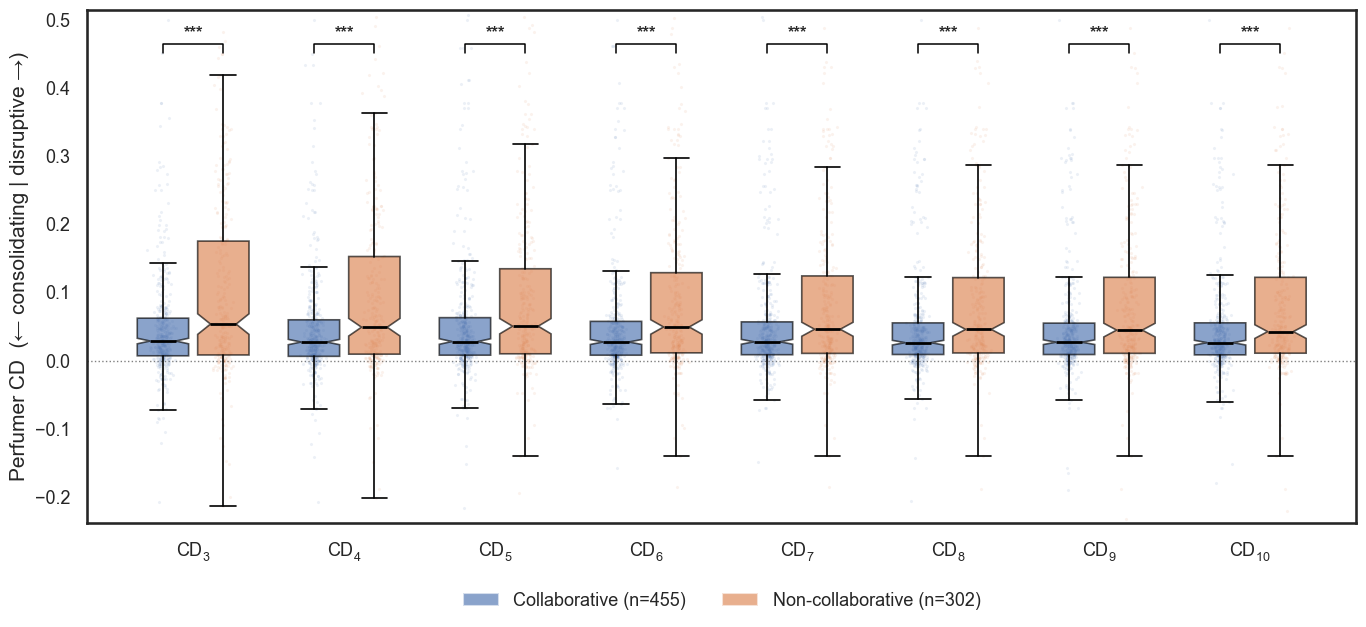

In [10]:
import os, sys
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from utils.utils import parse_perfumer, clean_perfumer_artifacts, compute_cd_indices

WINDOWS = list(range(3, 11))
MIN_PERF = 3

def main():
    df = pd.read_csv("../dataset/Fragrantica.csv",
                     usecols=['id', 'year', 'perfumer', 'brand', 'this_perfume_reminds_ids'])
    df['parsed_perfumers'] = [clean_perfumer_artifacts(parse_perfumer(p), h)
                              for p, h in zip(df['perfumer'], df['brand'])]
    cd = compute_cd_indices(df, windows=tuple(WINDOWS))
    df = df.merge(cd, on='id', how='left')

    collaborators = set()
    for pp in df['parsed_perfumers']:
        if len(set(pp)) >= 2:
            collaborators.update(pp)

    cdcols = [f'cd{w}' for w in WINDOWS]
    rows = [{'perfumer': p, **{c: r[c] for c in cdcols}}
            for _, r in df.iterrows() for p in set(r['parsed_perfumers'])]
    per = pd.DataFrame(rows).groupby('perfumer').agg(
        **{c: (c, 'mean') for c in cdcols}, n=('cd5', 'count')).reset_index()
    per = per[per['n'] >= MIN_PERF].copy()
    per['group'] = np.where(per['perfumer'].isin(collaborators), 'Collaborative', 'Non-collaborative')
    nC = (per['group'] == 'Collaborative').sum(); nN = (per['group'] == 'Non-collaborative').sum()
    print(f"perfumers (>= {MIN_PERF} CD-defined perfumes): {len(per)} "
          f"({nC} collaborative, {nN} non-collaborative)")

    long = per.melt(id_vars=['perfumer', 'group'], value_vars=cdcols, var_name='win', value_name='cd').dropna()
    long['window'] = long['win'].str.replace('cd', 'CD')
    order = [f'CD{w}' for w in WINDOWS]

    pvals = {}
    print("\nMann–Whitney U (Collaborative vs Non-collaborative):")
    for w in WINDOWS:
        a = per.loc[per['group'] == 'Collaborative', f'cd{w}'].dropna()
        b = per.loc[per['group'] == 'Non-collaborative', f'cd{w}'].dropna()
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        pvals[f'CD{w}'] = p
        print(f"  CD{w}: collab median={a.median():+.3f} | non median={b.median():+.3f} | p={p:.2e}")

    sns.set_style("white"); sns.set_context("talk")
    from matplotlib.patches import Patch
    pal = {'Collaborative': '#4C72B0', 'Non-collaborative': '#DD8452'}; groups = list(pal)
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(14, 6.6))
    off, width = 0.2, 0.34
    def _whiskers(v):
        v = np.asarray(v); q1, q3 = np.percentile(v, [25, 75]); iqr = q3 - q1
        lo = v[v >= q1 - 1.5 * iqr]; hi = v[v <= q3 + 1.5 * iqr]
        return (lo.min() if len(lo) else v.min(), hi.max() if len(hi) else v.max())
    _wl, _wh = [], []
    for w in WINDOWS:
        for g in groups:
            vals = per.loc[per['group'] == g, f'cd{w}'].dropna().values
            if len(vals):
                a, b = _whiskers(vals); _wl.append(a); _wh.append(b)
    ylo, yhi = min(_wl), max(_wh); span = yhi - ylo
    ylo -= 0.04 * span   # extra room so the lower error-bar caps sit inside the plot
    for i, w in enumerate(WINDOWS):
        for g, sgn in zip(groups, (-1, +1)):
            vals = per.loc[per['group'] == g, f'cd{w}'].dropna().values
            xp = i + sgn * off
            ax.scatter(rng.normal(xp, 0.028, len(vals)), vals, s=5, alpha=0.10,
                       color=pal[g], zorder=1, linewidths=0)
            bp = ax.boxplot([vals], notch=True, widths=width, patch_artist=True, showfliers=False,
                            positions=[xp], zorder=3, medianprops=dict(color='black', lw=2),
                            whiskerprops=dict(color='black', lw=1.2), capprops=dict(color='black', lw=1.2),
                            boxprops=dict(lw=1.2))
            bp['boxes'][0].set_facecolor(pal[g]); bp['boxes'][0].set_alpha(0.65)
    ax.axhline(0, color='gray', ls=':', lw=1, zorder=0)
    def stars(pv): return '***' if pv < 1e-3 else '**' if pv < 1e-2 else '*' if pv < 0.05 else 'n.s.'
    yb = yhi + 0.05 * span
    for i, w in enumerate(WINDOWS):
        ax.plot([i - off, i - off, i + off, i + off],
                [yb, yb + 0.02 * span, yb + 0.02 * span, yb], color='black', lw=1.1)
        ax.text(i, yb + 0.03 * span, stars(pvals[f'CD{w}']), ha='center', va='bottom',
                fontsize=12, fontweight='bold')
    ax.set_ylim(ylo, yhi + 0.15 * span)
    ax.set_xticks(range(len(WINDOWS))); ax.set_xticklabels([f"CD$_{{{w}}}$" for w in WINDOWS], fontsize=20)
    # ax.set_xlabel("CD Window (years)", fontsize=17)
    ax.set_ylabel("Perfumer CD  (← consolidating | disruptive →)", fontsize=15)
    ax.legend(handles=[Patch(facecolor=pal[g], alpha=0.65,
                             label=f"{g} (n={(per['group'] == g).sum()})") for g in groups],
              frameon=False, fontsize=13, loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=2)
    ax.tick_params(labelsize=13)
    for _sp in ax.spines.values():
        _sp.set_visible(True)
    plt.tight_layout()
    plt.savefig("../output/Figure_S13.pdf", format="pdf", dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    main()